#**Justificación del cambio de la base de datos**

## Justificación del cambio de base de datos

En la Tarea 1 se trabajó con ENAHO porque esa fuente permitía reproducir y adaptar los scripts vistos en clase sobre bases estructuradas, con énfasis en limpieza, integración de módulos, construcción de variables y análisis exploratorio. El objetivo principal era mostrar que los ejercicios del curso podían traducirse en una investigación social empírica inicial. La Tarea 1 ya había seguido precisamente esa estructura: un objeto acotado, niveles analíticos explícitos y un pipeline claro de archivo bruto, auditoría, limpieza, ensamblaje y exportación. De hecho hice otra aplicación de la Tarea 1 usando datos de la ENAHOPV.


*   ENAHO: https://drive.google.com/drive/folders/1kGelQ58J8dW5JrUsjWZy-EMdjn9-w2u5?usp=drive_link

*   ENAHOPV: https://drive.google.com/drive/folders/1-6n6P8Mo9jFb7XxCpzVNx5_Lr6n2Wg3E?usp=drive_link

Para la Tarea 2, sin embargo, cambia. Ya no se trata solamente de trabajar con una base previamente descargada, sino de aprender a inspeccionar una arquitectura web, identificar enlaces, comprender el tipo de fuente, automatizar descargas y construir un flujo reproducible de obtención de datos. En ese sentido, reemplazar ENAHO por el Portal de Datos Abiertos del OECE resulta más pertinente para esta etapa del curso. Además, la temática de contrataciones públicas se vincula de manera inmediata con transparencia, rendición de cuentas, mercado de información estatal y análisis aplicado al Estado.

El cambio de base, por tanto, no implica abandonar la rigurosidad académica, sino trasladarla a un objeto más cercano al campo profesional. Si ENAHO fue adecuada para ejercitar el tratamiento de bases estadísticas y la formalización de un problema social, OECE es más adecuada para ejercitar la obtención, inspección, documentación y ensamblaje de datos administrativos desde una plataforma web dinámica.

## Delimitación del objeto de estudio

La Tarea 2 no abordará el universo completo de las contrataciones públicas ni la totalidad de módulos del Portal de Datos Abiertos del OECE. Para mantener un alcance modesto, posible y lograble, el objeto específico será la arquitectura de acceso y descarga del módulo “Datos de la Convocatoria o Invitación”, dentro del portal de datos abiertos del OECE.

La unidad inicial de trabajo no será “la contratación pública peruana” en abstracto, sino los archivos tabulares descargables que la plataforma ofrece para ese módulo, organizados por año y por tipo de descarga. La subpágina de convocatorias presenta una estructura anual desde 2018 hasta 2026, y que para cada año ofrece tres vías de descarga: todos los procesos, solo subasta inversa electrónica y solo contratación directa. En consecuencia, el objeto de la Tarea 2 puede formularse así:

###**Arquitectura de las convocatorias adjudicadas en la contratación pública peruana: web scraping, ensamblaje y análisis exploratorio desde el portal de datos abiertos del OECE**

## Inspección de la página web

La inspección inicial permite distinguir tres niveles: la portada general del portal, la subpágina elegida y el patrón técnico de descarga. La ficha oficial del servicio en gob.pe la describe como "[..]un instrumento para descargar información del Plan Anual de Contrataciones, procedimientos adjudicados, proveedores adjudicados y datos complementarios, con la finalidad de incrementar la transparencia, fortalecer la rendición de cuentas y facilitar la creación de un mercado de información sobre compras públicas".

En la subpágina "Datos de la Convocatoria o Invitación”, se observa una estructura seriada por años. Cada bloque anual contiene íconos de descarga, la indicación “Formato Excel” y tres botones diferenciados. Desde un punto de vista metodológico, esta organización es especialmente valiosa porque estamos ante una interfaz repetitiva, por año y por modalidad de descarga.

La interfaz no está completamente escrita como HTML estático tradicional, sino que existe una capa de renderizado o inyección dinámica del contenido visible. En términos prácticos, esto significa que el scraping no deberá pensarse solo como lectura directa del texto de la página, sino como identificación de nodos, botones, atributos y eventualmente enlaces disparados desde una estructura HTML asistida por JavaScript. El hecho de que la página se entregue como text/html sigue siendo favorable, porque permite trabajar con herramientas estándar de inspección y scraping web.

## Observación sobre el diccionario de datos

El diccionario muesta que el módulo de convocatorias está bien definido desde el punto de vista estructural. La hoja “Convocatoria Diccionario” contiene 28 variables y muestra que el dataset combina información de entidad, procedimiento, objeto contractual, montos, geografía del ítem y fechas relevantes. Entre las variables aparecen, por ejemplo, CODIGOENTIDAD, ENTIDAD_RUC, ENTIDAD, TIPOENTIDAD, CODIGOCONVOCATORIA, DESCRIPCION_PROCESO, TIPO_COMPRA, OBJETOCONTRACTUAL, SISTEMA_CONTRATACION, MONTOREFERENCIAL, DEPARTAMENTO_ITEM, PROVINCIA_ITEM, DISTRITO_ITEM, MONEDA, FECHA_CONVOCATORIA, FECHAINTEGRACIONBASES y FECHAPRESENTACIONPROPUESTA.


In [1]:
# ============================================================
# TAREA 2 — ESTRUCTURA DE CARPETAS EN GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2")

CARPETAS = [
    "00_admin",
    "01_insumos",
    "01_insumos/capturas_portal",
    "01_insumos/diccionario_datos",
    "01_insumos/indicaciones_curso",
    "01_insumos/referencias_teoricas",
    "02_fuente_web",
    "02_fuente_web/html_guardado",
    "02_fuente_web/enlaces_detectados",
    "02_fuente_web/metadata_descargas",
    "02_fuente_web/logs_scraping",
    "03_datos_brutos",
    "03_datos_brutos/convocatorias",
    "03_datos_brutos/convocatorias/2018",
    "03_datos_brutos/convocatorias/2019",
    "03_datos_brutos/convocatorias/2020",
    "03_datos_brutos/convocatorias/2021",
    "03_datos_brutos/convocatorias/2022",
    "03_datos_brutos/convocatorias/2023",
    "03_datos_brutos/convocatorias/2024",
    "03_datos_brutos/convocatorias/2025",
    "03_datos_brutos/convocatorias/2026",
    "04_datos_procesados",
    "04_datos_procesados/tablas_limpias",
    "04_datos_procesados/tablas_unificadas",
    "04_datos_procesados/auditorias",
    "04_datos_procesados/variables_derivadas",
    "05_notebooks",
    "06_scripts",
    "07_resultados",
    "07_resultados/tablas",
    "07_resultados/figuras",
    "07_resultados/resumenes",
    "08_presentacion",
    "08_presentacion/imagenes",
    "08_presentacion/borradores",
    "09_entrega"
]

for carpeta in CARPETAS:
    (BASE / carpeta).mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente en:")
print(BASE)

print("\nEstructura principal:")
for carpeta in [
    "00_admin",
    "01_insumos",
    "02_fuente_web",
    "03_datos_brutos",
    "04_datos_procesados",
    "05_notebooks",
    "06_scripts",
    "07_resultados",
    "08_presentacion",
    "09_entrega"
]:
    print("-", carpeta)

Mounted at /content/drive
Carpetas creadas correctamente en:
/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2

Estructura principal:
- 00_admin
- 01_insumos
- 02_fuente_web
- 03_datos_brutos
- 04_datos_procesados
- 05_notebooks
- 06_scripts
- 07_resultados
- 08_presentacion
- 09_entrega


In [2]:
# ============================================================
# VERIFICACIÓN RÁPIDA DE LA ESTRUCTURA
# ============================================================

from pathlib import Path

def mostrar_arbol(ruta: Path, max_nivel=2, nivel=0):
    if nivel > max_nivel:
        return
    prefijo = "    " * nivel
    print(f"{prefijo}- {ruta.name}/")
    for sub in sorted(ruta.iterdir()):
        if sub.is_dir():
            mostrar_arbol(sub, max_nivel=max_nivel, nivel=nivel+1)

mostrar_arbol(BASE, max_nivel=2)

- Tarea 2/
    - 00_admin/
    - 01_insumos/
        - capturas_portal/
        - diccionario_datos/
        - indicaciones_curso/
        - referencias_teoricas/
    - 02_fuente_web/
        - enlaces_detectados/
        - html_guardado/
        - logs_scraping/
        - metadata_descargas/
    - 03_datos_brutos/
        - convocatorias/
    - 04_datos_procesados/
        - auditorias/
        - tablas_limpias/
        - tablas_unificadas/
        - variables_derivadas/
    - 05_notebooks/
    - 06_scripts/
    - 07_resultados/
        - figuras/
        - resumenes/
        - tablas/
    - 08_presentacion/
        - borradores/
        - imagenes/
    - 09_entrega/


# Tarea 2 — Parte 1/3
# Formalización del objeto, justificación del cambio de base e inspección estructural del portal OECE

**Curso:** Fundamentos de Programación para IA Generativa Aplicada  
**Programa:** Especialización en IA Generativa aplicada a CCSS y Gestión Pública  

## Título de trabajo

**Arquitectura de las convocatorias adjudicadas en la contratación pública peruana: web scraping, ensamblaje y análisis exploratorio desde el portal de datos abiertos del OECE**

## Propósito de esta primera parte

Esta primera tiene el objetivo de construir el objeto de trabajo de manera rigurosa y reproducible, dejando listos:

1. la justificación del cambio de base de datos;
2. la delimitación precisa del objeto;
3. la inspección estructural del portal y de la subpágina seleccionada;
4. el inventario inicial de enlaces, botones, años y patrones visibles de descarga;
5. la exportación de metadatos y evidencia básica para la presentación de la Tarea 2.

## Idea metodológica

La tarea no tratará “contrataciones públicas” en abstracto ni “todo el portal OECE”. Trabajará con un objeto acotado, posible y lograble:
**la subpágina “Datos de la Convocatoria o Invitación”**.

## Secuencia de trabajo

**problema → fuente → inspección → evidencia estructural → inventario reproducible**

In [1]:
# ============================================================
# TAREA 2 — PARTE 1/3
# CONFIGURACIÓN DEL ENTORNO Y RUTAS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
import json
import os

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 250)

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2")

RUTA_ADMIN = BASE / "00_admin"
RUTA_INSUMOS = BASE / "01_insumos"
RUTA_CAPTURAS = RUTA_INSUMOS / "capturas_portal"
RUTA_DICCIONARIO = RUTA_INSUMOS / "diccionario_datos"

RUTA_FUENTE = BASE / "02_fuente_web"
RUTA_HTML = RUTA_FUENTE / "html_guardado"
RUTA_ENLACES = RUTA_FUENTE / "enlaces_detectados"
RUTA_META = RUTA_FUENTE / "metadata_descargas"
RUTA_LOGS = RUTA_FUENTE / "logs_scraping"

RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"
RUTA_PROCESADOS = BASE / "04_datos_procesados"
RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

for ruta in [
    RUTA_ADMIN, RUTA_INSUMOS, RUTA_CAPTURAS, RUTA_DICCIONARIO,
    RUTA_FUENTE, RUTA_HTML, RUTA_ENLACES, RUTA_META, RUTA_LOGS,
    RUTA_BRUTOS, RUTA_PROCESADOS, RUTA_RESULTADOS, RUTA_RESULTADOS_TABLAS, RUTA_RESULTADOS_RESUMENES
]:
    ruta.mkdir(parents=True, exist_ok=True)

print("Base de trabajo:", BASE)
print("HTML guardado :", RUTA_HTML)
print("Enlaces       :", RUTA_ENLACES)
print("Metadatos     :", RUTA_META)
print("Resultados    :", RUTA_RESULTADOS)

Mounted at /content/drive
Base de trabajo: /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2
HTML guardado : /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/02_fuente_web/html_guardado
Enlaces       : /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/02_fuente_web/enlaces_detectados
Metadatos     : /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/02_fuente_web/metadata_descargas
Resultados    : /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/07_resultados


In [2]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def buscar_archivo_por_fragmentos(directorio: Path, fragmentos: list[str]):
    candidatos = []
    if not directorio.exists():
        return None
    for archivo in directorio.iterdir():
        if archivo.is_file():
            nombre = normalizar_texto(archivo.name)
            if all(normalizar_texto(f) in nombre for f in fragmentos):
                candidatos.append(archivo)
    return sorted(candidatos)[0] if candidatos else None

def guardar_texto(ruta: Path, contenido: str):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(contenido)

def resumen_dataframe(df: pd.DataFrame, nombre: str):
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    display(df.head())

In [3]:
# ============================================================
# INVENTARIO DE LA ESTRUCTURA DE TRABAJO
# ============================================================

def listar_carpetas(base: Path, max_nivel=2, nivel=0, registros=None):
    if registros is None:
        registros = []
    if nivel > max_nivel:
        return registros
    for item in sorted(base.iterdir()):
        registros.append({
            "nivel": nivel,
            "tipo": "dir" if item.is_dir() else "file",
            "ruta": str(item.relative_to(BASE))
        })
        if item.is_dir():
            listar_carpetas(item, max_nivel=max_nivel, nivel=nivel+1, registros=registros)
    return registros

inventario_estructura = pd.DataFrame(listar_carpetas(BASE, max_nivel=2))
display(inventario_estructura.head(50))

inventario_estructura.to_csv(
    RUTA_ADMIN / "t2_parte1_inventario_estructura.csv",
    index=False,
    encoding="utf-8"
)

,nivel,tipo,ruta
0,0,dir,00_admin
1,0,dir,01_insumos
2,1,dir,01_insumos/capturas_portal
3,1,dir,01_insumos/diccionario_datos
4,1,dir,01_insumos/indicaciones_curso
5,1,dir,01_insumos/referencias_teoricas
6,0,dir,02_fuente_web
7,1,dir,02_fuente_web/enlaces_detectados
8,1,dir,02_fuente_web/html_guardado
9,1,dir,02_fuente_web/logs_scraping


## Justificación del cambio de base de datos

En la Tarea 1 se trabajó con ENAHO porque esa fuente permitía reproducir y adaptar los scripts vistos en clase sobre bases estructuradas, con énfasis en limpieza, integración de módulos, construcción de variables y análisis exploratorio. En ese momento, el objetivo principal era demostrar que los ejercicios del curso podían traducirse en una investigación social empírica inicial, manteniendo una lógica ordenada de delimitación del problema, definición de unidad de observación, ensamblaje de datos y modelización básica.

Para la Tarea 2, sin embargo, el centro metodológico cambia. Ya no se trata solamente de trabajar con una base previamente descargada, sino de inspeccionar una arquitectura web, identificar enlaces, verificar el tipo de fuente, automatizar la descarga y construir un flujo reproducible de obtención de datos. En ese sentido, resulta más pertinente reemplazar ENAHO por una fuente nativa de consulta y descarga digital.

El Portal de Datos Abiertos del OECE es adecuado para esta nueva etapa porque articula programación, automatización, gestión pública y uso profesional de datos administrativos. Además, su temática se vincula directamente con contrataciones públicas, transparencia, rendición de cuentas y análisis aplicado al Estado. Por ello, el cambio de base no implica abandonar la rigurosidad académica, sino trasladarla a un objeto más cercano al campo profesional.

En consecuencia, la Tarea 2 debe entenderse como un paso lógico entre la reproducción de scripts y el diseño de un flujo de trabajo aplicado.

## Delimitación del objeto

La Tarea 2 no abordará el universo completo de las contrataciones públicas ni la totalidad de módulos del Portal de Datos Abiertos del OECE. Para mantener un alcance modesto, posible y lograble, el objeto específico será la arquitectura de acceso y descarga del módulo:

**“Datos de la Convocatoria o Invitación”**

La unidad inicial de trabajo no será “la contratación pública peruana” en abstracto, sino los archivos tabulares descargables que la plataforma ofrece para ese módulo, organizados por año y por subtipo de descarga.

En esta primera parte se trabajará únicamente con:

1. la portada general del portal;
2. la subpágina de convocatorias;
3. la inspección de su estructura HTML visible;
4. el inventario de botones, enlaces y patrones de descarga.

No se realizará todavía la descarga masiva de archivos.  
Esa tarea quedará para la Parte 2/3.

In [4]:
# ============================================================
# URLS DE TRABAJO
# ============================================================

URL_PORTAL = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key"
URL_CONVOCATORIAS = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias"

tabla_urls = pd.DataFrame([
    {
        "objeto": "portal_principal",
        "url": URL_PORTAL,
        "descripcion": "Portada del Portal de Datos Abiertos del OECE"
    },
    {
        "objeto": "subpagina_convocatorias",
        "url": URL_CONVOCATORIAS,
        "descripcion": "Subpágina Datos de la Convocatoria o Invitación"
    }
])

display(tabla_urls)
tabla_urls.to_csv(RUTA_META / "t2_parte1_urls_trabajo.csv", index=False, encoding="utf-8")

,objeto,url,descripcion
0,portal_principal,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key,Portada del Portal de Datos Abiertos del OECE
1,subpagina_convocatorias,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,Subpágina Datos de la Convocatoria o Invitación


In [5]:
# ============================================================
# PAQUETES PARA INSPECCIÓN WEB
# ============================================================

!pip -q install requests beautifulsoup4 lxml openpyxl

In [6]:
# ============================================================
# INSPECCIÓN INICIAL DEL PORTAL Y DE LA SUBPÁGINA
# ============================================================

import requests
from bs4 import BeautifulSoup

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

def descargar_html(url: str, nombre_archivo: str):
    response = requests.get(url, headers=HEADERS, timeout=60)
    response.raise_for_status()
    html = response.text
    ruta = RUTA_HTML / nombre_archivo
    guardar_texto(ruta, html)
    return response, html, ruta

resp_portal, html_portal, ruta_portal = descargar_html(URL_PORTAL, "oece_portal_principal.html")
resp_conv, html_conv, ruta_conv = descargar_html(URL_CONVOCATORIAS, "oece_convocatorias.html")

print("Portal principal:", resp_portal.status_code, "->", ruta_portal.name)
print("Subpágina convocatorias:", resp_conv.status_code, "->", ruta_conv.name)

soup_portal = BeautifulSoup(html_portal, "lxml")
soup_conv = BeautifulSoup(html_conv, "lxml")

Portal principal: 200 -> oece_portal_principal.html
Subpágina convocatorias: 200 -> oece_convocatorias.html


In [7]:
# ============================================================
# VERIFICACIÓN DEL TIPO DE FUENTE
# ============================================================

meta_fuente = pd.DataFrame([
    {
        "pagina": "portal_principal",
        "status_code": resp_portal.status_code,
        "content_type": resp_portal.headers.get("Content-Type"),
        "url_final": resp_portal.url,
        "n_caracteres_html": len(html_portal)
    },
    {
        "pagina": "subpagina_convocatorias",
        "status_code": resp_conv.status_code,
        "content_type": resp_conv.headers.get("Content-Type"),
        "url_final": resp_conv.url,
        "n_caracteres_html": len(html_conv)
    }
])

display(meta_fuente)
meta_fuente.to_csv(RUTA_META / "t2_parte1_meta_fuente.csv", index=False, encoding="utf-8")

,pagina,status_code,content_type,url_final,n_caracteres_html
0,portal_principal,200,text/html,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adatosabiertos.html/content?userid=public&password=key,3333
1,subpagina_convocatorias,200,text/html,https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias,4964


In [8]:
# ============================================================
# EXTRACCIÓN DE ELEMENTOS VISIBLES BÁSICOS
# ============================================================

def extraer_elementos_basicos(soup, nombre):
    title = soup.title.text.strip() if soup.title else None
    h1 = [x.get_text(" ", strip=True) for x in soup.find_all(["h1", "h2"])]
    anchors = []
    for a in soup.find_all("a", href=True):
        anchors.append({
            "pagina": nombre,
            "texto": a.get_text(" ", strip=True),
            "href": a.get("href")
        })
    return title, h1, pd.DataFrame(anchors)

title_portal, h_portal, links_portal = extraer_elementos_basicos(soup_portal, "portal_principal")
title_conv, h_conv, links_conv = extraer_elementos_basicos(soup_conv, "subpagina_convocatorias")

print("Título portal:", title_portal)
print("Encabezados portal:", h_portal[:10])

print("\nTítulo convocatorias:", title_conv)
print("Encabezados convocatorias:", h_conv[:15])

df_links = pd.concat([links_portal, links_conv], ignore_index=True)
display(df_links.head(20))

df_links.to_csv(RUTA_ENLACES / "t2_parte1_links_html_raw.csv", index=False, encoding="utf-8")

Título portal: CONOSCE - DATOS ABIERTOS
Encabezados portal: []

Título convocatorias: CONOSCE - DATOS ABIERTOS
Encabezados convocatorias: []


""


In [9]:
# ============================================================
# INVENTARIO DE AÑOS Y BOTONES EN LA SUBPÁGINA DE CONVOCATORIAS
# ============================================================

texto_total_conv = soup_conv.get_text(" ", strip=True)
guardar_texto(RUTA_HTML / "oece_convocatorias_texto_plano.txt", texto_total_conv)

anios_detectados = re.findall(r"\b20(1[8-9]|2[0-6])\b", texto_total_conv)
anios_detectados = sorted(set(["20" + x for x in anios_detectados]))

tabla_anios = pd.DataFrame({"anio_detectado": anios_detectados})
display(tabla_anios)

tabla_anios.to_csv(RUTA_META / "t2_parte1_anios_detectados.csv", index=False, encoding="utf-8")

,anio_detectado


In [11]:
import itertools

# ============================================================
# INVENTARIO ESTRUCTURAL ASISTIDO DE LA SUBPÁGINA
# ============================================================

anios_esperados = [str(x) for x in range(2018, 2027)]

# Generate a flat list of dictionaries directly
estructura_esperada_data = []
for anio in anios_esperados:
    estructura_esperada_data.append({"anio": anio, "formato": "excel", "tipo_descarga": "todos_los_procesos"})
    estructura_esperada_data.append({"anio": anio, "formato": "excel", "tipo_descarga": "solo_subasta_inversa_electronica"})
    estructura_esperada_data.append({"anio": anio, "formato": "excel", "tipo_descarga": "solo_contratacion_directa"})

estructura_esperada = pd.DataFrame(estructura_esperada_data)

display(estructura_esperada.head(12))
estructura_esperada.to_csv(
    RUTA_META / "t2_parte1_estructura_esperada_convocatorias.csv",
    index=False,
    encoding="utf-8"
)

,anio,formato,tipo_descarga
0,2018,excel,todos_los_procesos
1,2018,excel,solo_subasta_inversa_electronica
2,2018,excel,solo_contratacion_directa
3,2019,excel,todos_los_procesos
4,2019,excel,solo_subasta_inversa_electronica
5,2019,excel,solo_contratacion_directa
6,2020,excel,todos_los_procesos
7,2020,excel,solo_subasta_inversa_electronica
8,2020,excel,solo_contratacion_directa
9,2021,excel,todos_los_procesos


In [12]:
# ============================================================
# LECTURA DEL DICCIONARIO DE DATOS
# ============================================================

ruta_diccionario = buscar_archivo_por_fragmentos(RUTA_DICCIONARIO, ["diccionario"])
print("Diccionario detectado:", ruta_diccionario)

if ruta_diccionario is not None:
    dic_raw = pd.read_excel(ruta_diccionario, sheet_name="Convocatoria Diccionario", header=None)
    display(dic_raw.head(12))

    dic = dic_raw.iloc[3:].copy()
    dic.columns = ["variable", "descripcion", "tipo_dato", "tamano", "recurso_relacionado", "informacion_adicional"]
    dic = dic[dic["variable"].notna()].copy()
    dic["variable"] = dic["variable"].astype(str).str.strip()
    dic = dic.reset_index(drop=True)

    display(dic.head(20))
    dic.to_csv(RUTA_META / "t2_parte1_diccionario_limpio.csv", index=False, encoding="utf-8")

    resumen_dic = pd.DataFrame([{
        "n_variables": len(dic),
        "n_variables_unicas": dic["variable"].nunique(),
        "tiene_campos_entidad": int(dic["variable"].astype(str).str.contains("ENTIDAD", case=False, regex=False).sum()),
        "tiene_campos_fecha": int(dic["variable"].astype(str).str.contains("FECHA", case=False, regex=False).sum()),
        "tiene_campos_monto": int(dic["variable"].astype(str).str.contains("MONTO", case=False, regex=False).sum()),
        "tiene_campos_geografia": int(dic["variable"].astype(str).str.contains("DEPARTAMENTO|PROVINCIA|DISTRITO", case=False, regex=True).sum())
    }])

    display(resumen_dic)
    resumen_dic.to_csv(RUTA_META / "t2_parte1_resumen_diccionario.csv", index=False, encoding="utf-8")
else:
    print("No se encontró el diccionario en 01_insumos/diccionario_datos.")

Diccionario detectado: None
No se encontró el diccionario en 01_insumos/diccionario_datos.


In [13]:
# ============================================================
# BITÁCORA METODOLÓGICA DE LA PARTE 1
# ============================================================

bitacora_parte1 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Definición de rutas y verificación de estructura de carpetas",
        "salida_principal": "Inventario de estructura"
    },
    {
        "paso": 2,
        "descripcion": "Formalización de URLs de trabajo",
        "salida_principal": "Tabla de URLs"
    },
    {
        "paso": 3,
        "descripcion": "Descarga y guardado del HTML bruto del portal y de la subpágina",
        "salida_principal": "Archivos HTML en 02_fuente_web/html_guardado"
    },
    {
        "paso": 4,
        "descripcion": "Verificación de tipo de fuente y metadatos básicos",
        "salida_principal": "Tabla meta_fuente"
    },
    {
        "paso": 5,
        "descripcion": "Extracción inicial de títulos, encabezados y enlaces",
        "salida_principal": "Links HTML raw"
    },
    {
        "paso": 6,
        "descripcion": "Inventario estructural de años y tipos de descarga",
        "salida_principal": "Estructura esperada de convocatorias"
    },
    {
        "paso": 7,
        "descripcion": "Lectura y resumen del diccionario de datos",
        "salida_principal": "Diccionario limpio y resumen de variables"
    }
])

display(bitacora_parte1)
bitacora_parte1.to_csv(RUTA_LOGS / "t2_parte1_bitacora_metodologica.csv", index=False, encoding="utf-8")

,paso,descripcion,salida_principal
0,1,Definición de rutas y verificación de estructura de carpetas,Inventario de estructura
1,2,Formalización de URLs de trabajo,Tabla de URLs
2,3,Descarga y guardado del HTML bruto del portal y de la subpágina,Archivos HTML en 02_fuente_web/html_guardado
3,4,Verificación de tipo de fuente y metadatos básicos,Tabla meta_fuente
4,5,"Extracción inicial de títulos, encabezados y enlaces",Links HTML raw
5,6,Inventario estructural de años y tipos de descarga,Estructura esperada de convocatorias
6,7,Lectura y resumen del diccionario de datos,Diccionario limpio y resumen de variables


## Cierre metodológico de la Parte 1/3

Esta primera parte permitió pasar de una intuición general sobre el portal OECE a una formalización empírica mínima y reproducible del objeto de trabajo.

En lugar de abordar todo el portal, se delimitó el módulo “Datos de la Convocatoria o Invitación” como unidad concreta de inspección. A partir de ello, se verificaron las URLs de trabajo, se guardó el HTML bruto, se revisó el tipo de fuente, se construyó un inventario inicial de enlaces y años visibles, y se incorporó el diccionario de datos como soporte para la futura lectura analítica del dataset.

Con ello, la tarea queda preparada para la Parte 2/3, donde ya no solo se inspeccionará la página, sino que se desarrollará la lógica de descarga automatizada, inventario de archivos y auditoría de paquetes descargados.

# Tarea 2 — Parte 2/3
# Descarga automatizada, auditoría de archivos e inventario reproducible

## Propósito de esta segunda parte

Esta parte desarrolla la fase operativa del scraping. Su objetivo es transformar la inspección estructural de la Parte 1/3 en una descarga controlada, auditable y reproducible de archivos del módulo: **“Datos de la Convocatoria o Invitación”**

## Alcance de esta parte

Para mantener un alcance modesto, posible y lograble, la descarga se realizará inicialmente sobre un subconjunto controlado:

- **Año objetivo:** 2022
- **Tipos de descarga:**
  - todos los procesos
  - solo subasta inversa electrónica
  - solo contratación directa

## Secuencia de trabajo

**estructura visible → Selenium → localización de botones → descarga → renombrado → auditoría → inventario**

In [14]:
# ============================================================
# TAREA 2 — PARTE 2/3
# REVALIDACIÓN DE RUTAS Y PARÁMETROS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import os
import re
import time
import json
import shutil
import unicodedata

# Revalidación de base y rutas
BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2")

RUTA_FUENTE = BASE / "02_fuente_web"
RUTA_HTML = RUTA_FUENTE / "html_guardado"
RUTA_ENLACES = RUTA_FUENTE / "enlaces_detectados"
RUTA_META = RUTA_FUENTE / "metadata_descargas"
RUTA_LOGS = RUTA_FUENTE / "logs_scraping"

RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"
RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

for ruta in [RUTA_HTML, RUTA_ENLACES, RUTA_META, RUTA_LOGS, RUTA_BRUTOS, RUTA_RESULTADOS_TABLAS, RUTA_RESULTADOS_RESUMENES]:
    ruta.mkdir(parents=True, exist_ok=True)

# URLs de trabajo
URL_CONVOCATORIAS = "https://bi.seace.gob.pe/pentaho/api/repos/%3Apublic%3Aportal%3Adataset.html/content?userid=public&password=key&pagina=convocatorias"

# Alcance controlado de esta parte
ANIOS_OBJETIVO = ["2022"]

MAPA_BOTONES = {
    "DESCARGAR TODOS LOS PROCESOS": "todos_los_procesos",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO SUBASTA INVERSA ELECTRONICA": "solo_subasta_inversa_electronica",
    "DESCARGAR SOLO CONTRATACIÓN DIRECTA": "solo_contratacion_directa",
    "DESCARGAR SOLO CONTRATACION DIRECTA": "solo_contratacion_directa"
}

print("Años objetivo:", ANIOS_OBJETIVO)
print("Ruta de brutos:", RUTA_BRUTOS)

Años objetivo: ['2022']
Ruta de brutos: /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias


In [15]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_espacios(texto: str) -> str:
    return re.sub(r"\s+", " ", str(texto)).strip()

def ruta_anio(anio: str) -> Path:
    ruta = RUTA_BRUTOS / anio
    ruta.mkdir(parents=True, exist_ok=True)
    return ruta

def esperar_descarga(download_dir: Path, archivos_antes: set, timeout=120, poll=1):
    """
    Espera hasta detectar un archivo nuevo descargado en download_dir.
    Ignora archivos temporales .crdownload.
    """
    inicio = time.time()
    while time.time() - inicio < timeout:
        archivos_actuales = set(download_dir.iterdir())
        nuevos = [p for p in archivos_actuales - archivos_antes if p.is_file()]
        finales = [p for p in nuevos if not p.name.endswith(".crdownload")]
        temporales = [p for p in nuevos if p.name.endswith(".crdownload")]

        if finales and not temporales:
            finales = sorted(finales, key=lambda p: p.stat().st_mtime, reverse=True)
            return finales[0]

        time.sleep(poll)

    return None

In [16]:
# ============================================================
# INSTALACIÓN DE SELENIUM Y CHROME
# ============================================================

!pip -q install selenium webdriver-manager openpyxl requests beautifulsoup4 lxml
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get install -f -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.8 MB/s eta 0:00:00
Selecting previously unselected package google-chrome-stable.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack google-chrome-stable_current_amd64.deb ...
Unpacking google-chrome-stable (147.0.7727.55-1) ...
dpkg: dependency problems prevent configuration of google-chrome-stable:
 google-chrome-stable depends on libatk-bridge2.0-0 (>= 2.5.3); however:
  Package libatk-bridge2.0-0 is not installed.
 google-chrome-stable depends on libatk1.0-0 (>= 2.11.90); however:
  Package libatk1.0-0 is not installed.
 google-chrome-stable depends on libatspi2.0-0 (>= 2.9.90); however:
  Package libatspi2.0-0 is not installed.
 google-chrome-stable depends on libvulkan1; however:
  Package libvulkan1 is not installed.
 goog

In [17]:
# ============================================================
# DRIVER CON PERMISO DE DESCARGA
# ============================================================

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

DOWNLOAD_DIR = RUTA_BRUTOS / "_temp_downloads"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

def crear_driver_descarga(download_dir: Path):
    opciones = Options()
    opciones.add_argument("--headless")
    opciones.add_argument("--no-sandbox")
    opciones.add_argument("--disable-dev-shm-usage")
    opciones.add_argument("--disable-gpu")
    opciones.add_argument("--window-size=1920,1080")
    opciones.add_argument("--remote-debugging-port=9222")
    opciones.binary_location = "/usr/bin/google-chrome"

    prefs = {
        "download.default_directory": str(download_dir),
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "safebrowsing.enabled": True
    }
    opciones.add_experimental_option("prefs", prefs)

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=opciones)

    # Permitir descargas en modo headless
    driver.execute_cdp_cmd(
        "Page.setDownloadBehavior",
        {"behavior": "allow", "downloadPath": str(download_dir)}
    )

    driver.maximize_window()
    return driver

driver = crear_driver_descarga(DOWNLOAD_DIR)
wait = WebDriverWait(driver, 25)

print("Driver inicializado correctamente.")
print("Directorio temporal de descarga:", DOWNLOAD_DIR)

Driver inicializado correctamente.
Directorio temporal de descarga: /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/_temp_downloads


In [18]:
# ============================================================
# HTML RENDERIZADO DE LA SUBPÁGINA
# ============================================================

driver.get(URL_CONVOCATORIAS)
time.sleep(6)

html_renderizado = driver.page_source

ruta_html_render = RUTA_HTML / "oece_convocatorias_renderizado.html"
with open(ruta_html_render, "w", encoding="utf-8") as f:
    f.write(html_renderizado)

print("HTML renderizado guardado en:", ruta_html_render)
print("Longitud del HTML renderizado:", len(html_renderizado))

HTML renderizado guardado en: /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/02_fuente_web/html_guardado/oece_convocatorias_renderizado.html
Longitud del HTML renderizado: 24877


In [19]:
# ============================================================
# LOCALIZACIÓN DE AÑO Y BOTONES
# ============================================================

def obtener_contenedor_anio(driver, anio: str, max_niveles=8):
    """
    Busca el elemento que contiene el año y asciende en el DOM
    hasta encontrar un contenedor con botones de descarga.
    """
    year_xpath = f"//*[normalize-space(text())='{anio}']"
    year_el = driver.find_element(By.XPATH, year_xpath)

    actual = year_el
    for _ in range(max_niveles):
        texto = normalizar_espacios(actual.text).upper()
        botones = actual.find_elements(By.XPATH, ".//button | .//a")
        textos_botones = [normalizar_espacios(b.text).upper() for b in botones if normalizar_espacios(b.text)]

        if "FORMATO EXCEL" in texto and any("DESCARGAR" in tb for tb in textos_botones):
            return actual

        actual = actual.find_element(By.XPATH, "..")

    return None

def extraer_botones_contenedor(contenedor):
    """
    Devuelve botones relevantes del contenedor anual.
    """
    candidatos = contenedor.find_elements(By.XPATH, ".//button | .//a")
    resultados = []

    for i, el in enumerate(candidatos, start=1):
        texto = normalizar_espacios(el.text)
        if not texto:
            continue
        if "DESCARGAR" not in texto.upper():
            continue

        resultados.append({
            "orden_boton": i,
            "texto_boton": texto,
            "tag": el.tag_name
        })

    return pd.DataFrame(resultados)

def encontrar_boton_por_texto(driver, anio: str, texto_objetivo: str):
    """
    Re-localiza el contenedor del año y devuelve el botón cuyo texto coincide.
    """
    contenedor = obtener_contenedor_anio(driver, anio)
    if contenedor is None:
        return None

    botones = contenedor.find_elements(By.XPATH, ".//button | .//a")
    for el in botones:
        texto = normalizar_espacios(el.text)
        if texto.upper() == texto_objetivo.upper():
            return el

    return None

In [20]:
# ============================================================
# INVENTARIO DE BOTONES VISIBLES
# ============================================================

inventario_botones = []

for anio in ANIOS_OBJETIVO:
    contenedor = obtener_contenedor_anio(driver, anio)
    if contenedor is None:
        inventario_botones.append({
            "anio": anio,
            "estado": "contenedor_no_detectado",
            "texto_boton": None,
            "tipo_descarga": None,
            "tag": None
        })
        continue

    df_botones = extraer_botones_contenedor(contenedor)
    if df_botones.empty:
        inventario_botones.append({
            "anio": anio,
            "estado": "sin_botones_detectados",
            "texto_boton": None,
            "tipo_descarga": None,
            "tag": None
        })
    else:
        for _, row in df_botones.iterrows():
            tipo = MAPA_BOTONES.get(row["texto_boton"].upper(), None)
            inventario_botones.append({
                "anio": anio,
                "estado": "ok",
                "texto_boton": row["texto_boton"],
                "tipo_descarga": tipo,
                "tag": row["tag"]
            })

df_inventario_botones = pd.DataFrame(inventario_botones)
display(df_inventario_botones)

df_inventario_botones.to_csv(
    RUTA_ENLACES / "t2_parte2_inventario_botones_renderizados.csv",
    index=False,
    encoding="utf-8"
)

,anio,estado,texto_boton,tipo_descarga,tag
0,2022,ok,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,a
1,2022,ok,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,a
2,2022,ok,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,a


In [21]:
# ============================================================
# DESCARGA CONTROLADA DE ARCHIVOS
# ============================================================

registro_descargas = []

for anio in ANIOS_OBJETIVO:
    carpeta_anio = ruta_anio(anio)

    filas_anio = df_inventario_botones[
        (df_inventario_botones["anio"] == anio) &
        (df_inventario_botones["estado"] == "ok") &
        (df_inventario_botones["tipo_descarga"].notna())
    ].copy()

    for _, fila in filas_anio.iterrows():
        texto_boton = fila["texto_boton"]
        tipo_descarga = fila["tipo_descarga"]

        try:
            boton = encontrar_boton_por_texto(driver, anio, texto_boton)
            if boton is None:
                raise ValueError(f"No se pudo re-localizar el botón: {texto_boton}")

            archivos_antes = set(DOWNLOAD_DIR.iterdir())

            driver.execute_script("arguments[0].scrollIntoView({block:'center'});", boton)
            time.sleep(1)
            driver.execute_script("arguments[0].click();", boton)

            archivo_descargado = esperar_descarga(DOWNLOAD_DIR, archivos_antes, timeout=180, poll=1)

            if archivo_descargado is None:
                raise TimeoutError("No se detectó archivo descargado dentro del tiempo esperado.")

            extension = archivo_descargado.suffix.lower() if archivo_descargado.suffix else ".xlsx"
            nombre_estandar = f"oece_convocatorias_{anio}_{tipo_descarga}{extension}"
            destino = carpeta_anio / nombre_estandar

            if destino.exists():
                destino.unlink()

            shutil.move(str(archivo_descargado), str(destino))

            registro_descargas.append({
                "anio": anio,
                "texto_boton": texto_boton,
                "tipo_descarga": tipo_descarga,
                "estado_descarga": "ok",
                "archivo_guardado": str(destino),
                "tamano_bytes": destino.stat().st_size
            })

            print(f"✓ Descarga correcta: {destino.name}")

            time.sleep(2)

        except Exception as e:
            registro_descargas.append({
                "anio": anio,
                "texto_boton": texto_boton,
                "tipo_descarga": tipo_descarga,
                "estado_descarga": "error",
                "archivo_guardado": None,
                "tamano_bytes": None,
                "error": str(e)
            })
            print(f"✗ Error en {anio} - {tipo_descarga}: {e}")

df_registro_descargas = pd.DataFrame(registro_descargas)
display(df_registro_descargas)

df_registro_descargas.to_csv(
    RUTA_LOGS / "t2_parte2_registro_descargas.csv",
    index=False,
    encoding="utf-8"
)

✓ Descarga correcta: oece_convocatorias_2022_todos_los_procesos.xlsx
✓ Descarga correcta: oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx
✓ Descarga correcta: oece_convocatorias_2022_solo_contratacion_directa.xlsx


,anio,texto_boton,tipo_descarga,estado_descarga,archivo_guardado,tamano_bytes
0,2022,DESCARGAR TODOS LOS PROCESOS,todos_los_procesos,ok,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_todos_los_procesos.xlsx,19795679
1,2022,DESCARGAR SOLO SUBASTA INVERSA ELECTRÓNICA,solo_subasta_inversa_electronica,ok,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,2081109
2,2022,DESCARGAR SOLO CONTRATACIÓN DIRECTA,solo_contratacion_directa,ok,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_contratacion_directa.xlsx,1490340


In [22]:
# ============================================================
# CIERRE DEL DRIVER
# ============================================================

driver.quit()
print("Driver cerrado correctamente.")

Driver cerrado correctamente.


In [23]:
# ============================================================
# INVENTARIO DE ARCHIVOS DESCARGADOS
# ============================================================

archivos_descargados = []

for anio in ANIOS_OBJETIVO:
    carpeta = ruta_anio(anio)
    for archivo in sorted(carpeta.glob("*")):
        if archivo.is_file():
            archivos_descargados.append({
                "anio": anio,
                "archivo": archivo.name,
                "ruta": str(archivo),
                "extension": archivo.suffix.lower(),
                "tamano_bytes": archivo.stat().st_size,
                "tamano_mb": round(archivo.stat().st_size / (1024**2), 3)
            })

df_archivos_descargados = pd.DataFrame(archivos_descargados)
display(df_archivos_descargados)

df_archivos_descargados.to_csv(
    RUTA_RESULTADOS_TABLAS / "t2_parte2_inventario_archivos_descargados.csv",
    index=False,
    encoding="utf-8"
)

,anio,archivo,ruta,extension,tamano_bytes,tamano_mb
0,2022,oece_convocatorias_2022_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_contratacion_directa.xlsx,.xlsx,1490340,1.421
1,2022,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,.xlsx,2081109,1.985
2,2022,oece_convocatorias_2022_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_todos_los_procesos.xlsx,.xlsx,19795679,18.879


In [24]:
# ============================================================
# INVENTARIO DE ARCHIVOS DESCARGADOS
# ============================================================

archivos_descargados = []

for anio in ANIOS_OBJETIVO:
    carpeta = ruta_anio(anio)
    for archivo in sorted(carpeta.glob("*")):
        if archivo.is_file():
            archivos_descargados.append({
                "anio": anio,
                "archivo": archivo.name,
                "ruta": str(archivo),
                "extension": archivo.suffix.lower(),
                "tamano_bytes": archivo.stat().st_size,
                "tamano_mb": round(archivo.stat().st_size / (1024**2), 3)
            })

df_archivos_descargados = pd.DataFrame(archivos_descargados)
display(df_archivos_descargados)

df_archivos_descargados.to_csv(
    RUTA_RESULTADOS_TABLAS / "t2_parte2_inventario_archivos_descargados.csv",
    index=False,
    encoding="utf-8"
)

,anio,archivo,ruta,extension,tamano_bytes,tamano_mb
0,2022,oece_convocatorias_2022_solo_contratacion_directa.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_contratacion_directa.xlsx,.xlsx,1490340,1.421
1,2022,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,.xlsx,2081109,1.985
2,2022,oece_convocatorias_2022_todos_los_procesos.xlsx,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_todos_los_procesos.xlsx,.xlsx,19795679,18.879


In [25]:
# ============================================================
# AUDITORÍA TÉCNICA DE EXCEL
# ============================================================

from openpyxl import load_workbook

auditoria_excel = []
columnas_excel = []

for _, fila in df_archivos_descargados.iterrows():
    ruta_archivo = Path(fila["ruta"])

    try:
        wb = load_workbook(ruta_archivo, read_only=True, data_only=True)
        hojas = wb.sheetnames

        for hoja in hojas:
            ws = wb[hoja]
            n_filas = ws.max_row
            n_columnas = ws.max_column

            auditoria_excel.append({
                "archivo": ruta_archivo.name,
                "anio": fila["anio"],
                "hoja": hoja,
                "n_filas_aprox": n_filas,
                "n_columnas_aprox": n_columnas
            })

        # leer encabezados de la primera hoja
        hoja0 = hojas[0]
        df_head = pd.read_excel(ruta_archivo, sheet_name=hoja0, nrows=5)
        cols = list(df_head.columns)

        for i, col in enumerate(cols, start=1):
            columnas_excel.append({
                "archivo": ruta_archivo.name,
                "anio": fila["anio"],
                "hoja": hoja0,
                "orden_columna": i,
                "columna": col
            })

    except Exception as e:
        auditoria_excel.append({
            "archivo": ruta_archivo.name,
            "anio": fila["anio"],
            "hoja": None,
            "n_filas_aprox": None,
            "n_columnas_aprox": None,
            "error": str(e)
        })

df_auditoria_excel = pd.DataFrame(auditoria_excel)
df_columnas_excel = pd.DataFrame(columnas_excel)

display(df_auditoria_excel)
display(df_columnas_excel.head(20))

df_auditoria_excel.to_csv(
    RUTA_RESULTADOS_TABLAS / "t2_parte2_auditoria_excel.csv",
    index=False,
    encoding="utf-8"
)

df_columnas_excel.to_csv(
    RUTA_RESULTADOS_TABLAS / "t2_parte2_columnas_excel.csv",
    index=False,
    encoding="utf-8"
)

,archivo,anio,hoja,n_filas_aprox,n_columnas_aprox
0,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,5466,28
1,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,2022,CONOSCE,8047,28
2,oece_convocatorias_2022_todos_los_procesos.xlsx,2022,CONOSCE,67890,28


,archivo,anio,hoja,orden_columna,columna
0,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,1,codigoentidad
1,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,2,entidad_ruc
2,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,3,entidad
3,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,4,tipoentidad
4,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,5,codigoconvocatoria
5,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,6,descripcion_proceso
6,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,7,proceso
7,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,8,tipocompra
8,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,9,objetocontractual
9,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022,CONOSCE,10,SECTOR / NIVEL DE GOBIERNO


In [26]:
# ============================================================
# COMPARACIÓN ESTRUCTURAL ENTRE PAQUETES 2022
# ============================================================

resumen_paquetes = (
    df_auditoria_excel
    .groupby("archivo", as_index=False)
    .agg(
        n_hojas=("hoja", "nunique"),
        n_filas_aprox=("n_filas_aprox", "max"),
        n_columnas_aprox=("n_columnas_aprox", "max")
    )
)

display(resumen_paquetes)
resumen_paquetes.to_csv(
    RUTA_RESULTADOS_RESUMENES / "t2_parte2_resumen_paquetes_2022.csv",
    index=False,
    encoding="utf-8"
)

comparacion_columnas = (
    df_columnas_excel
    .groupby("archivo")["columna"]
    .apply(list)
    .reset_index()
)

display(comparacion_columnas)
comparacion_columnas.to_csv(
    RUTA_RESULTADOS_RESUMENES / "t2_parte2_comparacion_columnas_2022.csv",
    index=False,
    encoding="utf-8"
)

,archivo,n_hojas,n_filas_aprox,n_columnas_aprox
0,oece_convocatorias_2022_solo_contratacion_directa.xlsx,1,5466,28
1,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,1,8047,28
2,oece_convocatorias_2022_todos_los_procesos.xlsx,1,67890,28


,archivo,columna
0,oece_convocatorias_2022_solo_contratacion_directa.xlsx,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, SECTOR / NIVEL DE GOBIERNO, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item..."
1,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, SECTOR / NIVEL DE GOBIERNO, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item..."
2,oece_convocatorias_2022_todos_los_procesos.xlsx,"[codigoentidad, entidad_ruc, entidad, tipoentidad, codigoconvocatoria, descripcion_proceso, proceso, tipocompra, objetocontractual, SECTOR / NIVEL DE GOBIERNO, sistema_contratacion, tipoprocesoseleccion, montoreferencial, n_item, descripcion_item..."


In [27]:
# ============================================================
# MUESTRA DE LECTURA INICIAL DE LOS TRES PAQUETES
# ============================================================

muestras = []

for _, fila in df_archivos_descargados.iterrows():
    ruta_archivo = Path(fila["ruta"])
    try:
        df_tmp = pd.read_excel(ruta_archivo, sheet_name=0, nrows=3)
        df_tmp["archivo_origen"] = ruta_archivo.name
        muestras.append(df_tmp)
    except Exception as e:
        print(f"No se pudo leer muestra de {ruta_archivo.name}: {e}")

if muestras:
    df_muestras = pd.concat(muestras, ignore_index=True)
    display(df_muestras.head(15))
    df_muestras.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte2_muestras_archivos_2022.csv",
        index=False,
        encoding="utf-8"
    )
else:
    print("No se generaron muestras de lectura.")

/tmp/ipykernel_11607/2402920252.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_muestras = pd.concat(muestras, ignore_index=True)


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,SECTOR / NIVEL DE GOBIERNO,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,archivo_origen
0,10247,20131369124,EJERCITO PERUANO,GOBIERNO NACIONAL,857128,"ADQUISICIÓN DE MATERIAL MÉDICO, INSUMOS Y REACTIVOS PARA LAS DISTINTAS ÁRES HOSPITALARIAS DEL HOSPITAL MILITAR CENTRAL",DIRECTA-PROC-7-2022-EP/UO 0794-1,Por la Entidad,Bien,DEFENSA,Suma alzada,Contratación Directa,3000000.00,6,ITEM PAQUETE 6,Unidad,Contratado,SI,NaN,NaN,47950.00,Soles,LIMA,LIMA,JESUS MARIA,2022-10-24,NaT,NaT,oece_convocatorias_2022_solo_contratacion_directa.xlsx
1,200560,20551239692,SUPERINTENDENCIA NACIONAL DE MIGRACIONES,GOBIERNO NACIONAL,800218,"Adquisición de Insumos para los Equipos de Impresión de Pasaporte Electrónico, de la Superintendencia Nacional de Migraciones.",DIRECTA-PROC-1-2022-MIGRACIONES-1,Por la Entidad,Bien,INTERIOR,Suma alzada,Contratación Directa,463740.20,1,"Insumos para los Equipos de Impresi¿n de Pasaporte Electr¿nico, de la Superintendencia Nacional de Migraciones",Unidad,Contratado,NO,356624.0,CABEZAL DE IMPRESION DE COLOR NEGRO PARA IMPRESORA LASER,463740.20,Soles,LIMA,LIMA,BREÑA,2022-04-28,NaT,NaT,oece_convocatorias_2022_solo_contratacion_directa.xlsx
2,200363,20538298485,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,GOBIERNO NACIONAL,776825,ADQUISICIÓN DE PRODUCTOS FARMACÉUTICOS PARA LA ATENCIÓN DE PACIENTES CON CORONAVIRUS EN EL MARCO DEL ESTADO DE EMERGENCIA SANITARIA POR COVID-19 (18 ÍTEMS),DIRECTA-PROC-15-2022-CENARES/ MINSA-1,Por la Entidad,Bien,SALUD,Suma alzada,Contratación Directa,16828028.80,5,CEFTRIAXONA 1GR AMP,Unidad,Contratado,NO,59513.0,CEFTRIAXONA 1 g INY,472670.00,Soles,LIMA,LIMA,JESUS MARIA,2022-02-07,NaT,NaT,oece_convocatorias_2022_solo_contratacion_directa.xlsx
3,2543,20131257750,SEGURO SOCIAL DE SALUD,FONAFE,826153,"Contratación del Suministro de Productos Farmacéuticos para los Establecimientos de Salud de las Redes Asistenciales de EsSalud, por un periodo de doce (12) meses - 28 ítems",SIE-SIE-28-2022-ESSALUD/CEABE-1,Por la Entidad,Bien,TRABAJO Y PROMOCIÓN DEL EMPLEO,Precios unitarios,Subasta Inversa Electrónica,90012312.54,24,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,Unidad,Contratado,NO,60296.0,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,2448385.80,Soles,LIMA,LIMA,JESUS MARIA,2022-07-19,NaT,2022-07-20,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx
4,1834,20147796715,MUNICIPALIDAD DISTRITAL DE ALTO DE LA ALIANZA,GOBIERNO LOCAL,821978,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN VELASCO ALVARADO DISTRITO ALTO DE LA ALIANZA, PROV...",SIE-SIE-15-2022-OEC-MDAA-1,Por la Entidad,Bien,GOBIERNO LOCAL,Precios unitarios,Subasta Inversa Electrónica,51030.00,1,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN VELASCO ALVARADO DISTRITO ALTO DE LA ALIANZA, PROV...",Unidad,Contratado,NO,12953.0,CEMENTO PORTLAND PUZOLANICO TIPO IP X 42.50 kg,51030.00,Soles,TACNA,TACNA,ALTO DE LA ALIANZA,2022-07-04,NaT,2022-07-05,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx
5,2349,20115425651,EMPRESA MUNICIPAL DE AGUA POTABLE Y ALCANTARILLADO DE ABANCAY S.A.,GOBIERNO LOCAL,784191,Contratación de suministro de cemento portland tipo I (4000 bolsas) para instalaciones y mantenimiento de conexiones domiciliarias de agua y desagüe ejercicio 2022.,SIE-SIE-2-2022-EMUSAP-ABANCAY-1,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Subasta Inversa Electr

In [28]:
# ============================================================
# BITÁCORA METODOLÓGICA DE LA PARTE 2
# ============================================================

bitacora_parte2 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Revalidación de rutas y definición del alcance controlado (2022)",
        "salida_principal": "Parámetros de trabajo"
    },
    {
        "paso": 2,
        "descripcion": "Configuración de Selenium y del directorio temporal de descarga",
        "salida_principal": "Driver con permiso de descarga"
    },
    {
        "paso": 3,
        "descripcion": "Guardado del HTML renderizado de la subpágina de convocatorias",
        "salida_principal": "Archivo HTML renderizado"
    },
    {
        "paso": 4,
        "descripcion": "Detección del contenedor del año y de los botones visibles",
        "salida_principal": "Inventario de botones renderizados"
    },
    {
        "paso": 5,
        "descripcion": "Descarga automatizada de los tres paquetes 2022",
        "salida_principal": "Registro de descargas y archivos renombrados"
    },
    {
        "paso": 6,
        "descripcion": "Inventario y auditoría técnica de los archivos descargados",
        "salida_principal": "Tablas de auditoría de Excel"
    },
    {
        "paso": 7,
        "descripcion": "Comparación estructural y muestra de lectura de paquetes",
        "salida_principal": "Resumen de paquetes 2022"
    }
])

display(bitacora_parte2)
bitacora_parte2.to_csv(
    RUTA_LOGS / "t2_parte2_bitacora_metodologica.csv",
    index=False,
    encoding="utf-8"
)

,paso,descripcion,salida_principal
0,1,Revalidación de rutas y definición del alcance controlado (2022),Parámetros de trabajo
1,2,Configuración de Selenium y del directorio temporal de descarga,Driver con permiso de descarga
2,3,Guardado del HTML renderizado de la subpágina de convocatorias,Archivo HTML renderizado
3,4,Detección del contenedor del año y de los botones visibles,Inventario de botones renderizados
4,5,Descarga automatizada de los tres paquetes 2022,Registro de descargas y archivos renombrados
5,6,Inventario y auditoría técnica de los archivos descargados,Tablas de auditoría de Excel
6,7,Comparación estructural y muestra de lectura de paquetes,Resumen de paquetes 2022


## Cierre metodológico de la Parte 2/3

La segunda parte permitió pasar de la inspección del portal a una extracción controlada y auditable de archivos del módulo “Datos de la Convocatoria o Invitación”.

En lugar de intentar descargar todo el portal, se trabajó con una ventana deliberadamente acotada: el año 2022 y sus tres paquetes principales. Esta decisión permitió verificar que la lógica de navegación observada en la Parte 1 podía traducirse en una secuencia reproducible de localización de botones, descarga automatizada, renombrado estandarizado, inventario y auditoría técnica.

Con ello, la tarea queda preparada para la Parte 3/3, donde los archivos descargados ya no serán tratados solo como objetos extraídos, sino como una base administrativa legible, comparable y susceptible de análisis exploratorio inicial.

# Tarea 2 — Parte 3/3
# Ensamblaje de bases, análisis exploratorio inicial y cierre metodológico

## Propósito de esta tercera parte

Esta parte transforma los archivos descargados en la Parte 2/3 en una base administrativa legible y analíticamente utilizable.

Su objetivo es:

1. leer y normalizar los tres paquetes 2022 descargados;
2. construir un objeto comparativo por paquete;
3. definir una base principal de análisis;
4. producir tablas y gráficos exploratorios;
5. dejar exportaciones listas para la presentación de la Tarea 2;
6. cerrar metodológicamente el ejercicio.

## Decisión analítica central

Los tres paquetes de 2022 no deben sumarse mecánicamente como si fueran universos independientes.  
Para evitar duplicación conceptual y empírica:

- la base **principal** de análisis será el archivo de **todos los procesos**;
- los archivos de **subasta inversa electrónica** y **contratación directa** serán usados como subconjuntos comparativos.

## Secuencia de trabajo

**archivos descargados → lectura → normalización → comparación estructural → base principal → análisis exploratorio → exportación**

In [29]:
# ============================================================
# TAREA 2 — PARTE 3/3
# REVALIDACIÓN DE RUTAS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import unicodedata
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 250)

BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2")

RUTA_BRUTOS = BASE / "03_datos_brutos" / "convocatorias"
RUTA_BRUTOS_2022 = RUTA_BRUTOS / "2022"

RUTA_PROCESADOS = BASE / "04_datos_procesados"
RUTA_AUDITORIAS = RUTA_PROCESADOS / "auditorias"
RUTA_TABLAS_LIMPIAS = RUTA_PROCESADOS / "tablas_limpias"
RUTA_TABLAS_UNIFICADAS = RUTA_PROCESADOS / "tablas_unificadas"
RUTA_VARIABLES = RUTA_PROCESADOS / "variables_derivadas"

RUTA_RESULTADOS = BASE / "07_resultados"
RUTA_RESULTADOS_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_RESULTADOS_FIGURAS = RUTA_RESULTADOS / "figuras"
RUTA_RESULTADOS_RESUMENES = RUTA_RESULTADOS / "resumenes"

for ruta in [
    RUTA_AUDITORIAS, RUTA_TABLAS_LIMPIAS, RUTA_TABLAS_UNIFICADAS, RUTA_VARIABLES,
    RUTA_RESULTADOS_TABLAS, RUTA_RESULTADOS_FIGURAS, RUTA_RESULTADOS_RESUMENES
]:
    ruta.mkdir(parents=True, exist_ok=True)

print("Ruta de archivos 2022:", RUTA_BRUTOS_2022)

Ruta de archivos 2022: /content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022


In [44]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def buscar_archivo_por_fragmentos(directorio: Path, fragmentos: list[str]):
    candidatos = []
    for archivo in directorio.iterdir():
        if archivo.is_file():
            nombre = normalizar_texto(archivo.name)
            if all(normalizar_texto(f) in nombre for f in fragmentos):
                candidatos.append(archivo)
    return sorted(candidatos)[0] if candidatos else None

def auditar_dataframe(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    resumen = pd.DataFrame({
        "variable": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean() * 100).round(2).values,
        "n_unicos": df.nunique(dropna=True).values
    })
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    return resumen.sort_values(["pct_missing", "variable"], ascending=[False, True]).reset_index(drop=True)

def buscar_columna_por_fragmentos(columnas, patrones):
    cols_norm = {c: normalizar_columna(c) for c in columnas}
    for patron in patrones:
        patron_norm = normalizar_columna(patron)
        # Prioritize exact match
        for col_original, col_norm in cols_norm.items():
            if col_norm == patron_norm: # Exact match
                return col_original
        # Then check for containment
        for col_original, col_norm in cols_norm.items():
            if patron_norm in col_norm: # Substring match
                return col_original
    return None

def convertir_monto_robusto(serie):
    s = serie.astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def limpiar_texto_basico(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

In [31]:
# ============================================================
# RESOLUCIÓN DE ARCHIVOS 2022
# ============================================================

ARCHIVOS_2022 = {
    "todos_los_procesos": buscar_archivo_por_fragmentos(RUTA_BRUTOS_2022, ["2022", "todos_los_procesos"]),
    "solo_subasta_inversa_electronica": buscar_archivo_por_fragmentos(RUTA_BRUTOS_2022, ["2022", "subasta_inversa"]),
    "solo_contratacion_directa": buscar_archivo_por_fragmentos(RUTA_BRUTOS_2022, ["2022", "contratacion_directa"]),
}

df_archivos_2022 = pd.DataFrame({
    "paquete": list(ARCHIVOS_2022.keys()),
    "ruta": [str(v) if v else None for v in ARCHIVOS_2022.values()],
    "estado": ["OK" if v else "FALTA" for v in ARCHIVOS_2022.values()]
})

display(df_archivos_2022)

if (df_archivos_2022["estado"] == "FALTA").any():
    raise FileNotFoundError("Falta al menos uno de los tres paquetes 2022 descargados en la Parte 2/3.")

,paquete,ruta,estado
0,todos_los_procesos,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_todos_los_procesos.xlsx,OK
1,solo_subasta_inversa_electronica,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,OK
2,solo_contratacion_directa,/content/drive/MyDrive/IA Generativa para CCSS/Tarea 2/03_datos_brutos/convocatorias/2022/oece_convocatorias_2022_solo_contratacion_directa.xlsx,OK


In [32]:
# ============================================================
# LECTURA Y NORMALIZACIÓN DE LOS PAQUETES
# ============================================================

def cargar_paquete_oece(path: Path, paquete: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=0)
    df.columns = [normalizar_columna(c) for c in df.columns]
    df["paquete_origen"] = paquete
    df["archivo_origen"] = path.name
    df["anio"] = 2022
    return df

df_todos = cargar_paquete_oece(ARCHIVOS_2022["todos_los_procesos"], "todos_los_procesos")
df_sie = cargar_paquete_oece(ARCHIVOS_2022["solo_subasta_inversa_electronica"], "solo_subasta_inversa_electronica")
df_cd = cargar_paquete_oece(ARCHIVOS_2022["solo_contratacion_directa"], "solo_contratacion_directa")

print("Dimensiones:")
print("Todos los procesos           :", df_todos.shape)
print("Subasta inversa electrónica :", df_sie.shape)
print("Contratación directa        :", df_cd.shape)

display(df_todos.head(3))
display(df_sie.head(3))
display(df_cd.head(3))

Dimensiones:
Todos los procesos           : (67889, 31)
Subasta inversa electrónica : (8046, 31)
Contratación directa        : (5465, 31)


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,paquete_origen,archivo_origen,anio
0,724,20200367376,MUNICIPALIDAD PROVINCIAL DE SANTA CRUZ,GOBIERNO LOCAL,863808,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA.",AS-SM-6-2022-MPSC/CS-2,Por la Entidad,Obra,GOBIERNO LOCAL,Precios unitarios,Adjudicación Simplificada,11672602.96,1,"CONTRATACI¿N PARA LA EJECUCI¿N DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA",Servicio,Contratado,NO,360065.0,CONSTRUCCION DE CAMINO VECINAL,11672602.96,Soles,CAJAMARCA,SANTA CRUZ,SANTA CRUZ,2022-11-14,2022-11-22,2022-11-25,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
1,10216,20171604355,HOSPITAL SANTA ROSA,GOBIERNO NACIONAL,837112,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590",LP-SM-3-2022-HSR-1,Por la Entidad,Bien,SALUD,Suma alzada,Licitación Pública,468755.17,1,MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO,Unidad,Contratado,SI,NaN,NaN,468755.17,Soles,LIMA,LIMA,PUEBLO LIBRE,2022-08-08,2022-09-02,2022-09-13,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
2,1841,20227623544,MUNICIPALIDAD DISTRITAL DE CIUDAD NUEVA,GOBIERNO LOCAL,790601,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA.,AS-SM-3-2022-CS-MDCN-T-2,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Adjudicación Simplificada,133459.87,1,"ADQUISICI¿N DE LADRILLO DE ARCILLA DE 10X14X24CM, LADRILLO PARA TECHO DE 15X30X30CM y LADRILLO PASTELERO 24X24X3CM PARA LA OBRA CREACI¿N DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA.",Unidad,Contratado,NO,147581.0,LADRILLO DE ARCILLA KING KONG DE 10 cm X 14 cm X 24 cm,133459.87,Soles,TACNA,TACNA,CIUDAD NUEVA,2022-03-28,2022-04-01,2022-04-06,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,paquete_origen,archivo_origen,anio
0,2543,20131257750,SEGURO SOCIAL DE SALUD,FONAFE,826153,"Contratación del Suministro de Productos Farmacéuticos para los Establecimientos de Salud de las Redes Asistenciales de EsSalud, por un periodo de doce (12) meses - 28 ítems",SIE-SIE-28-2022-ESSALUD/CEABE-1,Por la Entidad,Bien,TRABAJO Y PROMOCIÓN DEL EMPLEO,Precios unitarios,Subasta Inversa Electrónica,90012312.54,24,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,Unidad,Contratado,NO,60296.0,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,2448385.80,Soles,LIMA,LIMA,JESUS MARIA,2022-07-19,NaN,2022-07-20,solo_subasta_inversa_electronica,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,2022
1,1834,20147796715,MUNICIPALIDAD DISTRITAL DE ALTO DE LA ALIANZA,GOBIERNO LOCAL,821978,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN VELASCO ALVARADO DISTRITO ALTO DE LA ALIANZA, PROV...",SIE-SIE-15-2022-OEC-MDAA-1,Por la Entidad,Bien,GOBIERNO LOCAL,Precios unitarios,Subasta Inversa Electrónica,51030.00,1,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN VELASCO ALVARADO DISTRITO ALTO DE LA ALIANZA, PROV...",Unidad,Contratado,NO,12953.0,CEMENTO PORTLAND PUZOLANICO TIPO IP X 42.50 kg,51030.00,Soles,TACNA,TACNA,ALTO DE LA ALIANZA,2022-07-04,NaN,2022-07-05,solo_subasta_inversa_electronica,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,2022
2,2349,20115425651,EMPRESA MUNICIPAL DE AGUA POTABLE Y ALCANTARILLADO DE ABANCAY S.A.,GOBIERNO LOCAL,784191,Contratación de suministro de cemento portland tipo I (4000 bolsas) para instalaciones y mantenimiento de conexiones domiciliarias de agua y desagüe ejercicio 2022.,SIE-SIE-2-2022-EMUSAP-ABANCAY-1,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Subasta Inversa Electrónica,103836.67,1,CEMENTO PORTLAND TIPO I X 42.50 kg,Unidad,Contratado,NO,12771.0,CEMENTO PORTLAND TIPO I X 42.50 kg,103836.67,Soles,APURIMAC,ABANCAY,ABANCAY,2022-03-08,NaN,2022-03-09,solo_subasta_inversa_electronica,oece_convocatorias_2022_solo_subasta_inversa_electronica.xlsx,2022


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,paquete_origen,archivo_origen,anio
0,10247,20131369124,EJERCITO PERUANO,GOBIERNO NACIONAL,857128,"ADQUISICIÓN DE MATERIAL MÉDICO, INSUMOS Y REACTIVOS PARA LAS DISTINTAS ÁRES HOSPITALARIAS DEL HOSPITAL MILITAR CENTRAL",DIRECTA-PROC-7-2022-EP/UO 0794-1,Por la Entidad,Bien,DEFENSA,Suma alzada,Contratación Directa,3000000.0,6,ITEM PAQUETE 6,Unidad,Contratado,SI,NaN,NaN,47950.0,Soles,LIMA,LIMA,JESUS MARIA,2022-10-24,NaN,NaN,solo_contratacion_directa,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022
1,200560,20551239692,SUPERINTENDENCIA NACIONAL DE MIGRACIONES,GOBIERNO NACIONAL,800218,"Adquisición de Insumos para los Equipos de Impresión de Pasaporte Electrónico, de la Superintendencia Nacional de Migraciones.",DIRECTA-PROC-1-2022-MIGRACIONES-1,Por la Entidad,Bien,INTERIOR,Suma alzada,Contratación Directa,463740.2,1,"Insumos para los Equipos de Impresi¿n de Pasaporte Electr¿nico, de la Superintendencia Nacional de Migraciones",Unidad,Contratado,NO,356624.0,CABEZAL DE IMPRESION DE COLOR NEGRO PARA IMPRESORA LASER,463740.2,Soles,LIMA,LIMA,BREÑA,2022-04-28,NaN,NaN,solo_contratacion_directa,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022
2,200363,20538298485,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,GOBIERNO NACIONAL,776825,ADQUISICIÓN DE PRODUCTOS FARMACÉUTICOS PARA LA ATENCIÓN DE PACIENTES CON CORONAVIRUS EN EL MARCO DEL ESTADO DE EMERGENCIA SANITARIA POR COVID-19 (18 ÍTEMS),DIRECTA-PROC-15-2022-CENARES/ MINSA-1,Por la Entidad,Bien,SALUD,Suma alzada,Contratación Directa,16828028.8,5,CEFTRIAXONA 1GR AMP,Unidad,Contratado,NO,59513.0,CEFTRIAXONA 1 g INY,472670.0,Soles,LIMA,LIMA,JESUS MARIA,2022-02-07,NaN,NaN,solo_contratacion_directa,oece_convocatorias_2022_solo_contratacion_directa.xlsx,2022


In [33]:
# ============================================================
# AUDITORÍA ESTRUCTURAL
# ============================================================

aud_todos = auditar_dataframe(df_todos, "df_todos")
aud_sie = auditar_dataframe(df_sie, "df_sie")
aud_cd = auditar_dataframe(df_cd, "df_cd")

aud_todos.to_csv(RUTA_AUDITORIAS / "t2_parte3_auditoria_todos.csv", index=False, encoding="utf-8")
aud_sie.to_csv(RUTA_AUDITORIAS / "t2_parte3_auditoria_sie.csv", index=False, encoding="utf-8")
aud_cd.to_csv(RUTA_AUDITORIAS / "t2_parte3_auditoria_cd.csv", index=False, encoding="utf-8")

tabla_dimensiones = pd.DataFrame([
    {"paquete": "todos_los_procesos", "filas": len(df_todos), "columnas": df_todos.shape[1]},
    {"paquete": "solo_subasta_inversa_electronica", "filas": len(df_sie), "columnas": df_sie.shape[1]},
    {"paquete": "solo_contratacion_directa", "filas": len(df_cd), "columnas": df_cd.shape[1]},
])

display(tabla_dimensiones)
tabla_dimensiones.to_csv(RUTA_RESULTADOS_RESUMENES / "t2_parte3_dimensiones_paquetes.csv", index=False, encoding="utf-8")

df_todos: 67,889 filas × 31 columnas
df_sie: 8,046 filas × 31 columnas
df_cd: 5,465 filas × 31 columnas


,paquete,filas,columnas
0,todos_los_procesos,67889,31
1,solo_subasta_inversa_electronica,8046,31
2,solo_contratacion_directa,5465,31


In [34]:
# ============================================================
# COMPARACIÓN ESTRUCTURAL DE COLUMNAS
# ============================================================

cols_todos = set(df_todos.columns)
cols_sie = set(df_sie.columns)
cols_cd = set(df_cd.columns)

columnas_comunes = sorted(cols_todos & cols_sie & cols_cd)
solo_todos = sorted(cols_todos - cols_sie - cols_cd)
solo_sie = sorted(cols_sie - cols_todos - cols_cd)
solo_cd = sorted(cols_cd - cols_todos - cols_sie)

tabla_columnas = pd.DataFrame([
    {
        "n_columnas_todos": len(cols_todos),
        "n_columnas_sie": len(cols_sie),
        "n_columnas_cd": len(cols_cd),
        "n_columnas_comunes": len(columnas_comunes),
        "columnas_iguales_en_los_tres": int(cols_todos == cols_sie == cols_cd)
    }
])

display(tabla_columnas)

pd.DataFrame({"columnas_comunes": columnas_comunes}).to_csv(
    RUTA_AUDITORIAS / "t2_parte3_columnas_comunes.csv",
    index=False,
    encoding="utf-8"
)

tabla_columnas.to_csv(
    RUTA_AUDITORIAS / "t2_parte3_resumen_columnas.csv",
    index=False,
    encoding="utf-8"
)

,n_columnas_todos,n_columnas_sie,n_columnas_cd,n_columnas_comunes,columnas_iguales_en_los_tres
0,31,31,31,31,1


In [35]:
# ============================================================
# BASE COMPARATIVA APILADA
# ============================================================

base_paquetes_2022 = pd.concat([df_todos, df_sie, df_cd], ignore_index=True)
display(base_paquetes_2022.head())

base_paquetes_2022.to_csv(
    RUTA_TABLAS_UNIFICADAS / "t2_parte3_base_paquetes_2022.csv",
    index=False,
    encoding="utf-8"
)

/tmp/ipykernel_11607/732997795.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_paquetes_2022 = pd.concat([df_todos, df_sie, df_cd], ignore_index=True)


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,paquete_origen,archivo_origen,anio
0,724,20200367376,MUNICIPALIDAD PROVINCIAL DE SANTA CRUZ,GOBIERNO LOCAL,863808,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA.",AS-SM-6-2022-MPSC/CS-2,Por la Entidad,Obra,GOBIERNO LOCAL,Precios unitarios,Adjudicación Simplificada,11672602.96,1,"CONTRATACI¿N PARA LA EJECUCI¿N DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA",Servicio,Contratado,NO,360065.0,CONSTRUCCION DE CAMINO VECINAL,11672602.96,Soles,CAJAMARCA,SANTA CRUZ,SANTA CRUZ,2022-11-14,2022-11-22,2022-11-25,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
1,10216,20171604355,HOSPITAL SANTA ROSA,GOBIERNO NACIONAL,837112,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590",LP-SM-3-2022-HSR-1,Por la Entidad,Bien,SALUD,Suma alzada,Licitación Pública,468755.17,1,MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO,Unidad,Contratado,SI,NaN,NaN,468755.17,Soles,LIMA,LIMA,PUEBLO LIBRE,2022-08-08,2022-09-02,2022-09-13,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
2,1841,20227623544,MUNICIPALIDAD DISTRITAL DE CIUDAD NUEVA,GOBIERNO LOCAL,790601,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA.,AS-SM-3-2022-CS-MDCN-T-2,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Adjudicación Simplificada,133459.87,1,"ADQUISICI¿N DE LADRILLO DE ARCILLA DE 10X14X24CM, LADRILLO PARA TECHO DE 15X30X30CM y LADRILLO PASTELERO 24X24X3CM PARA LA OBRA CREACI¿N DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA.",Unidad,Contratado,NO,147581.0,LADRILLO DE ARCILLA KING KONG DE 10 cm X 14 cm X 24 cm,133459.87,Soles,TACNA,TACNA,CIUDAD NUEVA,2022-03-28,2022-04-01,2022-04-06,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
3,8,20131378972,CONTRALORIA GENERAL DE LA REPUBLICA,GOBIERNO NACIONAL,876354,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR,AS-SM-24-2022-C.G.R.-2,Por la Entidad,Bien,SIN SECTOR,Precios unitarios,Adjudicación Simplificada,163764.00,1,ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,Galon,Contratado,NO,129874.0,GASOHOL 97 PLUS,163764.00,Soles,LIMA,LIMA,JESUS MARIA,2022-12-28,2023-01-06,2023-01-13,todos_los_procesos,oece_convocatorias_2022_todos_los_procesos.xlsx,2022
4,1540,20171880115,MUNICIPALIDAD DISTRITAL DE TORATA,GOBIERNO LOCAL,792598,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL DISTRITO DE TORATA - PROVINCIAL MARISCAL NIETO - ...,SIE-SIE-15-2022-OEC/MDT-1,Por la Entidad,Bien,GOBIERNO LOCAL,Precios unitarios,Subasta Inversa Electrónica,525000.00,1,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) ¿ COPLAY ¿ NUEVO COPLAY ¿ DOCE QUEBRADAS ¿ NUEVA ESPERANZA ¿ BUENA VISTA ONCE DEL DISTRITO DE TORATA ¿ PROVINCIAL MARISCAL NIETO ¿ ...,Unidad,Contratado,NO,12771.0,CEMENTO PORTLAND TIPO I X 42.50 kg,525000.00,Soles,MOQUEGUA,MARISCAL NI

In [36]:
# ============================================================
# BASE PRINCIPAL DE ANÁLISIS
# ============================================================

base_principal_2022 = df_todos.copy()

print("Base principal seleccionada: todos_los_procesos")
print("Forma:", base_principal_2022.shape)

Base principal seleccionada: todos_los_procesos
Forma: (67889, 31)


In [45]:
# ============================================================
# IDENTIFICACIÓN DE VARIABLES CLAVE
# ============================================================

col_codigo_entidad = buscar_columna_por_fragmentos(base_principal_2022.columns, ["codigoentidad"])
col_entidad = buscar_columna_por_fragmentos(base_principal_2022.columns, ["entidad"])
col_tipo_entidad = buscar_columna_por_fragmentos(base_principal_2022.columns, ["tipoentidad"])
col_codigo_conv = buscar_columna_por_fragmentos(base_principal_2022.columns, ["codigoconvocatoria"])
col_desc_proceso = buscar_columna_por_fragmentos(base_principal_2022.columns, ["descripcion_proceso"])
col_tipo_compra = buscar_columna_por_fragmentos(base_principal_2022.columns, ["tipocompra"])
col_objeto = buscar_columna_por_fragmentos(base_principal_2022.columns, ["objetocontractual"])
col_tipo_proceso = buscar_columna_por_fragmentos(base_principal_2022.columns, ["tipoprocesoseleccion"])
col_sistema = buscar_columna_por_fragmentos(base_principal_2022.columns, ["sistema_contratacion"])
col_monto = buscar_columna_por_fragmentos(base_principal_2022.columns, ["montoreferencial"])
col_moneda = buscar_columna_por_fragmentos(base_principal_2022.columns, ["moneda"])
col_dep = buscar_columna_por_fragmentos(base_principal_2022.columns, ["departamento_item"])
col_prov = buscar_columna_por_fragmentos(base_principal_2022.columns, ["provincia_item"])
col_dist = buscar_columna_por_fragmentos(base_principal_2022.columns, ["distrito_item"])
col_fecha_conv = buscar_columna_por_fragmentos(base_principal_2022.columns, ["fecha_convocatoria"])
col_fecha_bases = buscar_columna_por_fragmentos(base_principal_2022.columns, ["fechaintegracionbases"])
col_fecha_prop = buscar_columna_por_fragmentos(base_principal_2022.columns, ["fechapresentacionpropuesta"])
col_desc_item = buscar_columna_por_fragmentos(base_principal_2022.columns, ["descripcion_item"])

variables_detectadas = pd.DataFrame([
    {"variable_logica": "codigo_entidad", "columna_detectada": col_codigo_entidad},
    {"variable_logica": "entidad", "columna_detectada": col_entidad},
    {"variable_logica": "tipo_entidad", "columna_detectada": col_tipo_entidad},
    {"variable_logica": "codigo_convocatoria", "columna_detectada": col_codigo_conv},
    {"variable_logica": "descripcion_proceso", "columna_detectada": col_desc_proceso},
    {"variable_logica": "tipo_compra", "columna_detectada": col_tipo_compra},
    {"variable_logica": "objeto_contractual", "columna_detectada": col_objeto},
    {"variable_logica": "tipo_proceso", "columna_detectada": col_tipo_proceso},
    {"variable_logica": "sistema_contratacion", "columna_detectada": col_sistema},
    {"variable_logica": "monto_referencial", "columna_detectada": col_monto},
    {"variable_logica": "moneda", "columna_detectada": col_moneda},
    {"variable_logica": "departamento_item", "columna_detectada": col_dep},
    {"variable_logica": "provincia_item", "columna_detectada": col_prov},
    {"variable_logica": "distrito_item", "columna_detectada": col_dist},
    {"variable_logica": "fecha_convocatoria", "columna_detectada": col_fecha_conv},
    {"variable_logica": "fecha_integracion_bases", "columna_detectada": col_fecha_bases},
    {"variable_logica": "fecha_presentacion_propuesta", "columna_detectada": col_fecha_prop},
    {"variable_logica": "descripcion_item", "columna_detectada": col_desc_item},
])

display(variables_detectadas)
variables_detectadas.to_csv(RUTA_VARIABLES / "t2_parte3_variables_detectadas.csv", index=False, encoding="utf-8")

,variable_logica,columna_detectada
0,codigo_entidad,codigoentidad
1,entidad,entidad
2,tipo_entidad,tipoentidad
3,codigo_convocatoria,codigoconvocatoria
4,descripcion_proceso,descripcion_proceso
5,tipo_compra,tipocompra
6,objeto_contractual,objetocontractual
7,tipo_proceso,tipoprocesoseleccion
8,sistema_contratacion,sistema_contratacion
9,monto_referencial,montoreferencial


In [46]:
# ============================================================
# TABLA LIMPIA DE TRABAJO
# ============================================================

columnas_trabajo = {
    "codigo_entidad": col_codigo_entidad,
    "entidad": col_entidad,
    "tipo_entidad": col_tipo_entidad,
    "codigo_convocatoria": col_codigo_conv,
    "descripcion_proceso": col_desc_proceso,
    "tipo_compra": col_tipo_compra,
    "objeto_contractual": col_objeto,
    "tipo_proceso": col_tipo_proceso,
    "sistema_contratacion": col_sistema,
    "monto_referencial": col_monto,
    "moneda": col_moneda,
    "departamento_item": col_dep,
    "provincia_item": col_prov,
    "distrito_item": col_dist,
    "fecha_convocatoria": col_fecha_conv,
    "fecha_integracion_bases": col_fecha_bases,
    "fecha_presentacion_propuesta": col_fecha_prop,
    "descripcion_item": col_desc_item,
}

columnas_existentes = {k: v for k, v in columnas_trabajo.items() if v is not None}

base_trabajo_2022 = base_principal_2022[[v for v in columnas_existentes.values()]].copy()
base_trabajo_2022 = base_trabajo_2022.rename(columns={v: k for k, v in columnas_existentes.items()})

# variables adicionales
base_trabajo_2022["anio"] = 2022
base_trabajo_2022["paquete_principal"] = "todos_los_procesos"

if "monto_referencial" in base_trabajo_2022.columns:
    base_trabajo_2022["monto_referencial_num"] = convertir_monto_robusto(base_trabajo_2022["monto_referencial"])

if "fecha_convocatoria" in base_trabajo_2022.columns:
    base_trabajo_2022["fecha_convocatoria_dt"] = pd.to_datetime(
        base_trabajo_2022["fecha_convocatoria"], errors="coerce"
    )
    base_trabajo_2022["mes_convocatoria"] = base_trabajo_2022["fecha_convocatoria_dt"].dt.to_period("M").astype("string")

if "descripcion_proceso" in base_trabajo_2022.columns:
    base_trabajo_2022["descripcion_proceso_limpia"] = base_trabajo_2022["descripcion_proceso"].apply(limpiar_texto_basico)
    base_trabajo_2022["n_caracteres_descripcion"] = base_trabajo_2022["descripcion_proceso"].astype(str).str.len()

# llave analítica tentativa
if "codigo_convocatoria" in base_trabajo_2022.columns:
    base_trabajo_2022["llave_convocatoria"] = base_trabajo_2022["codigo_convocatoria"].astype(str).str.strip()
else:
    base_trabajo_2022["llave_convocatoria"] = (
        base_trabajo_2022.get("entidad", "").astype(str) + " | " +
        base_trabajo_2022.get("descripcion_proceso", "").astype(str) + " | " +
        base_trabajo_2022.get("fecha_convocatoria", "").astype(str)
    )

display(base_trabajo_2022.head())
base_trabajo_2022.to_csv(
    RUTA_TABLAS_LIMPIAS / "t2_parte3_base_trabajo_2022.csv",
    index=False,
    encoding="utf-8"
)

,codigo_entidad,entidad,tipo_entidad,codigo_convocatoria,descripcion_proceso,tipo_compra,objeto_contractual,tipo_proceso,sistema_contratacion,monto_referencial,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fecha_integracion_bases,fecha_presentacion_propuesta,descripcion_item,anio,paquete_principal,monto_referencial_num,fecha_convocatoria_dt,mes_convocatoria,descripcion_proceso_limpia,n_caracteres_descripcion,llave_convocatoria
0,724,MUNICIPALIDAD PROVINCIAL DE SANTA CRUZ,GOBIERNO LOCAL,863808,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA.",Por la Entidad,Obra,Adjudicación Simplificada,Precios unitarios,11672602.96,Soles,CAJAMARCA,SANTA CRUZ,SANTA CRUZ,2022-11-14,2022-11-22,2022-11-25,"CONTRATACI¿N PARA LA EJECUCI¿N DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE CAJAMARCA",2022,todos_los_procesos,11672602.96,2022-11-14,2022-11,contratacion para la ejecucion de la obra mejoramiento del camino vecinal r entre las localidades de pulan la achira y litcan del distrito de pulan provincia de santa cruz departamento de cajamarca,209,863808
1,10216,HOSPITAL SANTA ROSA,GOBIERNO NACIONAL,837112,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590",Por la Entidad,Bien,Licitación Pública,Suma alzada,468755.17,Soles,LIMA,LIMA,PUEBLO LIBRE,2022-08-08,2022-09-02,2022-09-13,MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO,2022,todos_los_procesos,468755.17,2022-08-08,2022-08,adquisicion de equipo microscopio quirurgico oftalmologico para el hospital de apoyo santa rosa lima pueblo libre en el marco del ioarr ciu,150,837112
2,1841,MUNICIPALIDAD DISTRITAL DE CIUDAD NUEVA,GOBIERNO LOCAL,790601,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA.,Por la Entidad,Bien,Adjudicación Simplificada,Suma alzada,133459.87,Soles,TACNA,TACNA,CIUDAD NUEVA,2022-03-28,2022-04-01,2022-04-06,"ADQUISICI¿N DE LADRILLO DE ARCILLA DE 10X14X24CM, LADRILLO PARA TECHO DE 15X30X30CM y LADRILLO PASTELERO 24X24X3CM PARA LA OBRA CREACI¿N DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA.",2022,todos_los_procesos,133459.87,2022-03-28,2022-03,adquisicion de ladrillos para la obra creacion de los servicios funerarios y de sepultura en el sector viii alto ciudad nueva distrito de ciudad nueva provincia de tacna departamento de tacna,196,790601
3,8,CONTRALORIA GENERAL DE LA REPUBLICA,GOBIERNO NACIONAL,876354,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR,Por la Entidad,Bien,Adjudicación Simplificada,Precios unitarios,163764.00,Soles,LIMA,LIMA,JESUS MARIA,2022-12-28,2023-01-06,2023-01-13,ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,2022,todos_los_procesos,163764.00,2022-12-28,2022-12,suministro de combustible gasohol para la flota vehicular de la sede central de la cgr,89,876354
4,1540,MUNICIPALIDAD DISTRITAL DE TORATA,GOBIERNO LOCAL,792598,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL DISTRITO DE TORATA - PROVINCIAL MARISCAL NIETO - ...,Por la Entidad,Bien,Subasta Inversa Electrónica,Precios unitarios,525000.00,Soles,MOQUEGUA,MARISCAL NIETO,MOQUEGUA,2022-04-01,NaT,2022-04-04,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) ¿ COPLAY ¿ NUEVO COPLAY ¿ DOCE QUEBRADAS ¿ NUEVA ESPERANZA ¿ BUENA VISTA ONCE DEL DISTRITO DE TORATA ¿ 

In [47]:
# ============================================================
# RESUMEN GENERAL DE LA BASE PRINCIPAL
# ============================================================

resumen_general = {
    "n_registros": len(base_trabajo_2022),
    "n_convocatorias_unicas": base_trabajo_2022["llave_convocatoria"].nunique(dropna=True),
    "n_entidades_unicas": base_trabajo_2022["entidad"].nunique(dropna=True) if "entidad" in base_trabajo_2022.columns else np.nan,
    "n_departamentos_unicos": base_trabajo_2022["departamento_item"].nunique(dropna=True) if "departamento_item" in base_trabajo_2022.columns else np.nan,
    "pct_con_monto": base_trabajo_2022["monto_referencial_num"].notna().mean() * 100 if "monto_referencial_num" in base_trabajo_2022.columns else np.nan,
    "monto_promedio": base_trabajo_2022["monto_referencial_num"].mean() if "monto_referencial_num" in base_trabajo_2022.columns else np.nan,
    "monto_mediano": base_trabajo_2022["monto_referencial_num"].median() if "monto_referencial_num" in base_trabajo_2022.columns else np.nan,
    "fecha_min": base_trabajo_2022["fecha_convocatoria_dt"].min() if "fecha_convocatoria_dt" in base_trabajo_2022.columns else pd.NaT,
    "fecha_max": base_trabajo_2022["fecha_convocatoria_dt"].max() if "fecha_convocatoria_dt" in base_trabajo_2022.columns else pd.NaT,
}

tabla_resumen_general = pd.DataFrame([resumen_general])
display(tabla_resumen_general)

tabla_resumen_general.to_csv(
    RUTA_RESULTADOS_RESUMENES / "t2_parte3_resumen_general_base_principal.csv",
    index=False,
    encoding="utf-8"
)

,n_registros,n_convocatorias_unicas,n_entidades_unicas,n_departamentos_unicos,pct_con_monto,monto_promedio,monto_mediano,fecha_min,fecha_max
0,67889,59381,2804,27,100.0,1.771161e+06,189911.67,2022-01-04,2022-12-31


In [48]:
# ============================================================
# COBERTURA DE VARIABLES CLAVE
# ============================================================

variables_clave = [
    "llave_convocatoria", "entidad", "tipo_entidad", "descripcion_proceso",
    "tipo_compra", "objeto_contractual", "tipo_proceso", "sistema_contratacion",
    "monto_referencial_num", "moneda", "departamento_item", "provincia_item",
    "distrito_item", "fecha_convocatoria_dt", "descripcion_item"
]

tabla_cobertura = pd.DataFrame({
    "variable": variables_clave,
    "n_validos": [base_trabajo_2022[v].notna().sum() if v in base_trabajo_2022.columns else np.nan for v in variables_clave],
    "pct_validos": [base_trabajo_2022[v].notna().mean() * 100 if v in base_trabajo_2022.columns else np.nan for v in variables_clave]
})

display(tabla_cobertura.round(2))
tabla_cobertura.to_csv(
    RUTA_RESULTADOS_TABLAS / "t2_parte3_cobertura_variables_clave.csv",
    index=False,
    encoding="utf-8"
)

,variable,n_validos,pct_validos
0,llave_convocatoria,67889,100.00
1,entidad,67889,100.00
2,tipo_entidad,67889,100.00
3,descripcion_proceso,67889,100.00
4,tipo_compra,67889,100.00
5,objeto_contractual,67889,100.00
6,tipo_proceso,67889,100.00
7,sistema_contratacion,67888,100.00
8,monto_referencial_num,67889,100.00
9,moneda,67889,100.00


In [49]:
# ============================================================
# COMPARACIÓN ENTRE PAQUETES 2022
# ============================================================

tabla_paquetes = (
    base_paquetes_2022
    .groupby("paquete_origen", as_index=False)
    .agg(
        n_registros=("paquete_origen", "count"),
        n_columnas=("archivo_origen", lambda s: base_paquetes_2022.shape[1])
    )
)

display(tabla_paquetes)
tabla_paquetes.to_csv(
    RUTA_RESULTADOS_RESUMENES / "t2_parte3_tabla_paquetes_2022.csv",
    index=False,
    encoding="utf-8"
)

# Cobertura de subconjuntos dentro del archivo general
if col_codigo_conv is not None:
    key_general = set(df_todos[col_codigo_conv].astype(str).dropna().str.strip())
    key_sie = df_sie[col_codigo_conv].astype(str).dropna().str.strip()
    key_cd = df_cd[col_codigo_conv].astype(str).dropna().str.strip()

    tabla_cobertura_subconjuntos = pd.DataFrame([
        {
            "subconjunto": "solo_subasta_inversa_electronica",
            "n_registros": len(key_sie),
            "pct_codigos_presentes_en_todos": (key_sie.isin(key_general)).mean() * 100 if len(key_sie) > 0 else np.nan
        },
        {
            "subconjunto": "solo_contratacion_directa",
            "n_registros": len(key_cd),
            "pct_codigos_presentes_en_todos": (key_cd.isin(key_general)).mean() * 100 if len(key_cd) > 0 else np.nan
        }
    ])

    display(tabla_cobertura_subconjuntos.round(2))
    tabla_cobertura_subconjuntos.to_csv(
        RUTA_RESULTADOS_RESUMENES / "t2_parte3_cobertura_subconjuntos_en_general.csv",
        index=False,
        encoding="utf-8"
    )

,paquete_origen,n_registros,n_columnas
0,solo_contratacion_directa,5465,31
1,solo_subasta_inversa_electronica,8046,31
2,todos_los_procesos,67889,31


,subconjunto,n_registros,pct_codigos_presentes_en_todos
0,solo_subasta_inversa_electronica,8046,100.0
1,solo_contratacion_directa,5465,100.0


,objeto_contractual,n,pct
0,Bien,32868,48.41
1,Servicio,22742,33.50
2,Obra,7946,11.70
3,Consultoría de Obra,4333,6.38


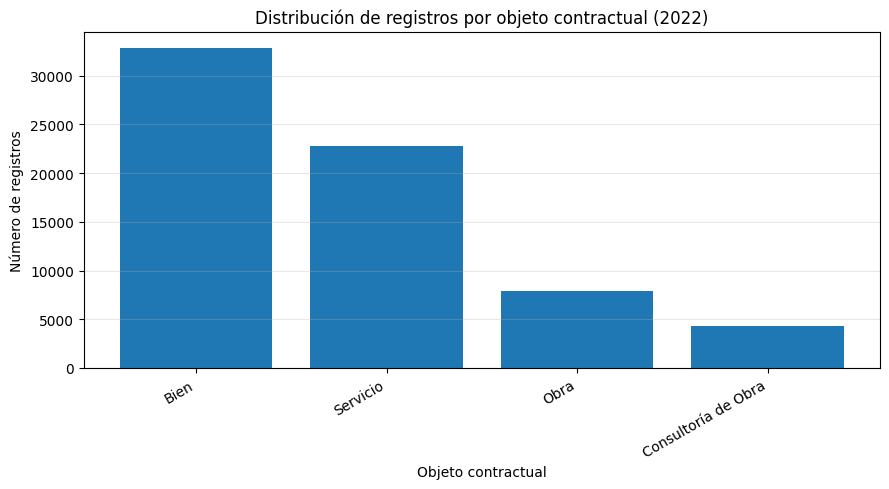

In [50]:
# ============================================================
# DISTRIBUCIÓN POR OBJETO CONTRACTUAL
# ============================================================

if "objeto_contractual" in base_trabajo_2022.columns:
    tabla_objeto = (
        base_trabajo_2022["objeto_contractual"]
        .fillna("sin_dato")
        .value_counts(dropna=False)
        .rename_axis("objeto_contractual")
        .reset_index(name="n")
    )
    tabla_objeto["pct"] = tabla_objeto["n"] / tabla_objeto["n"].sum() * 100

    display(tabla_objeto.round(2))
    tabla_objeto.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte3_objeto_contractual.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(tabla_objeto["objeto_contractual"], tabla_objeto["n"])
    ax.set_title("Distribución de registros por objeto contractual (2022)")
    ax.set_xlabel("Objeto contractual")
    ax.set_ylabel("Número de registros")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_objeto_contractual.png", dpi=300, bbox_inches="tight")
    plt.show()

,entidad,n_registros
0,SEGURO SOCIAL DE SALUD,2171
1,ORGANISMO DE EVALUACION Y FISCALIZACION AMBIENTAL,1469
2,EJERCITO PERUANO,1233
3,FUERZA AEREA DEL PERU,955
4,PETROLEOS DEL PERU S.A.,671
5,MINISTERIO DE CULTURA,649
6,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,592
7,GOBIERNO REGIONAL DE PUNO SEDE CENTRAL,559
8,MARINA DE GUERRA DEL PERU,527
9,PROGRAMA NACIONAL DE INVESTIGACIÓN CIENTÍFICA Y ESTUDIOS AVANZADOS,502


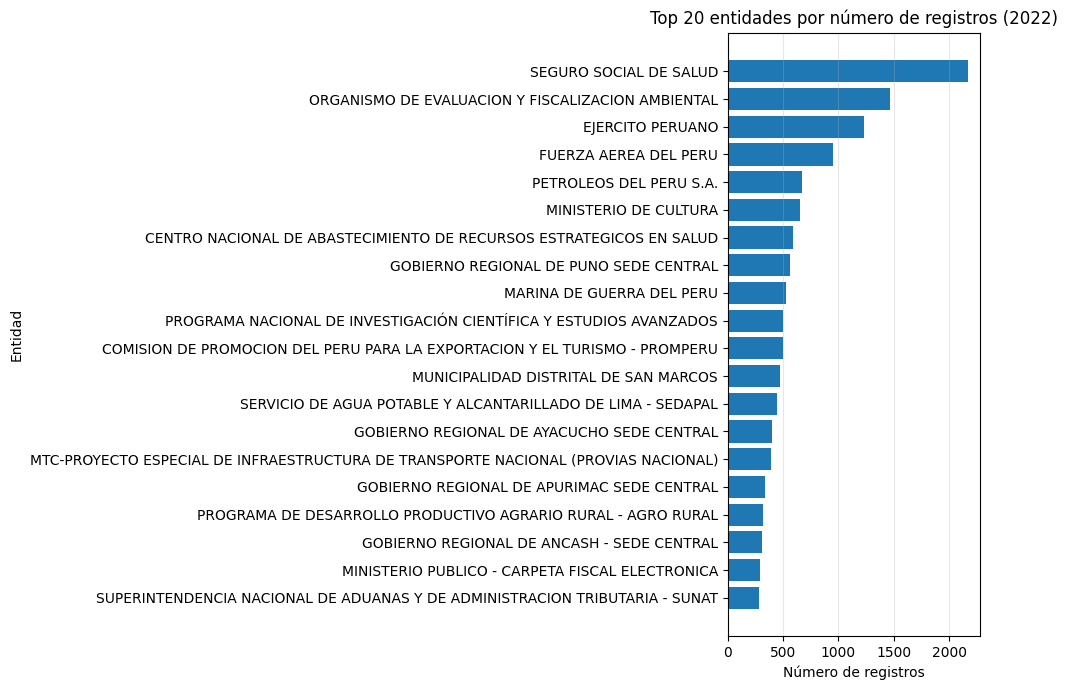

In [51]:
# ============================================================
# TOP ENTIDADES POR NÚMERO DE REGISTROS
# ============================================================

if "entidad" in base_trabajo_2022.columns:
    tabla_entidades = (
        base_trabajo_2022["entidad"]
        .fillna("sin_dato")
        .value_counts()
        .head(20)
        .rename_axis("entidad")
        .reset_index(name="n_registros")
    )

    display(tabla_entidades)
    tabla_entidades.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte3_top_entidades.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(tabla_entidades["entidad"][::-1], tabla_entidades["n_registros"][::-1])
    ax.set_title("Top 20 entidades por número de registros (2022)")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel("Entidad")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_top_entidades.png", dpi=300, bbox_inches="tight")
    plt.show()

,departamento_item,n_registros
0,LIMA,18564
1,CUSCO,6465
2,ANCASH,4113
3,PUNO,3030
4,PIURA,2937
5,AREQUIPA,2802
6,LA LIBERTAD,2544
7,CAJAMARCA,2510
8,JUNIN,2413
9,AYACUCHO,2265


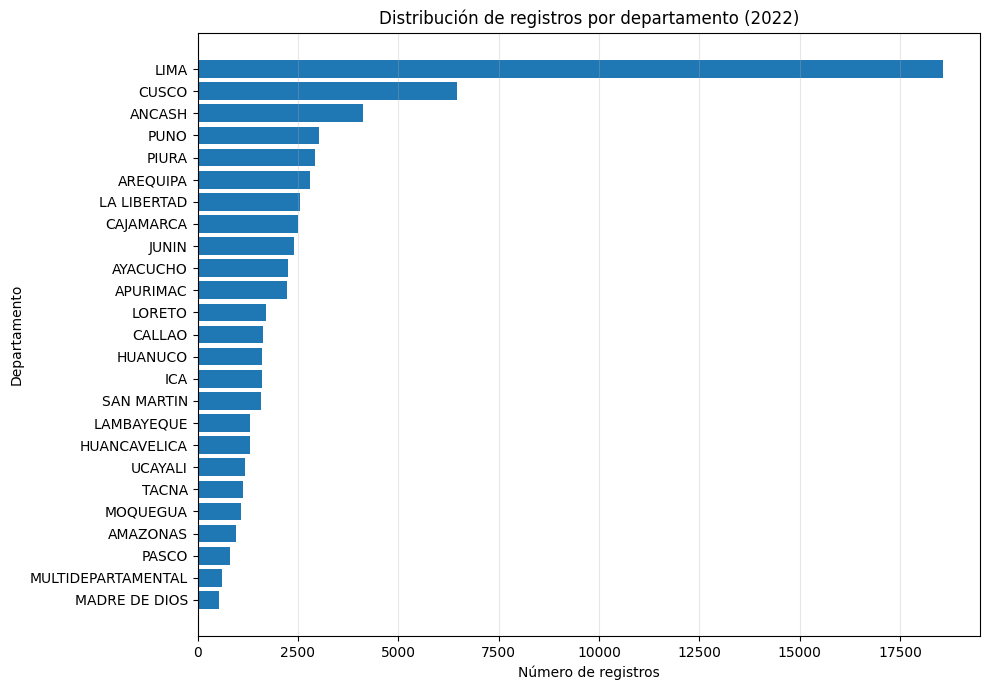

In [52]:
# ============================================================
# DISTRIBUCIÓN TERRITORIAL
# ============================================================

if "departamento_item" in base_trabajo_2022.columns:
    tabla_departamentos = (
        base_trabajo_2022["departamento_item"]
        .fillna("sin_dato")
        .value_counts()
        .head(25)
        .rename_axis("departamento_item")
        .reset_index(name="n_registros")
    )

    display(tabla_departamentos)
    tabla_departamentos.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte3_departamentos.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(tabla_departamentos["departamento_item"][::-1], tabla_departamentos["n_registros"][::-1])
    ax.set_title("Distribución de registros por departamento (2022)")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel("Departamento")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_departamentos.png", dpi=300, bbox_inches="tight")
    plt.show()

,mes_convocatoria,n_registros
0,2022-01,1231
1,2022-02,3846
2,2022-03,6772
3,2022-04,5739
4,2022-05,7256
5,2022-06,5959
6,2022-07,5875
7,2022-08,6230
8,2022-09,7061
9,2022-10,6546


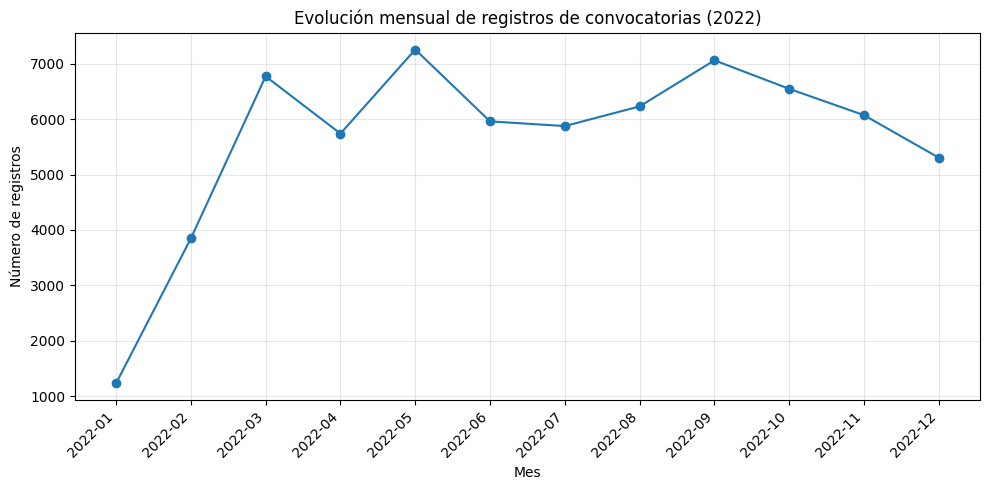

In [53]:
# ============================================================
# TRAYECTORIA TEMPORAL DE CONVOCATORIAS
# ============================================================

if "mes_convocatoria" in base_trabajo_2022.columns:
    tabla_mensual = (
        base_trabajo_2022
        .dropna(subset=["mes_convocatoria"])
        .groupby("mes_convocatoria", as_index=False)
        .agg(n_registros=("llave_convocatoria", "count"))
        .sort_values("mes_convocatoria")
    )

    display(tabla_mensual)
    tabla_mensual.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte3_convocatorias_mensuales.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tabla_mensual["mes_convocatoria"], tabla_mensual["n_registros"], marker="o")
    ax.set_title("Evolución mensual de registros de convocatorias (2022)")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Número de registros")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_convocatorias_mensuales.png", dpi=300, bbox_inches="tight")
    plt.show()

,n_validos,promedio,mediana,p25,p75,maximo
0,67889,1771160.71,189911.67,79663.37,542027.67,7.930787e+08


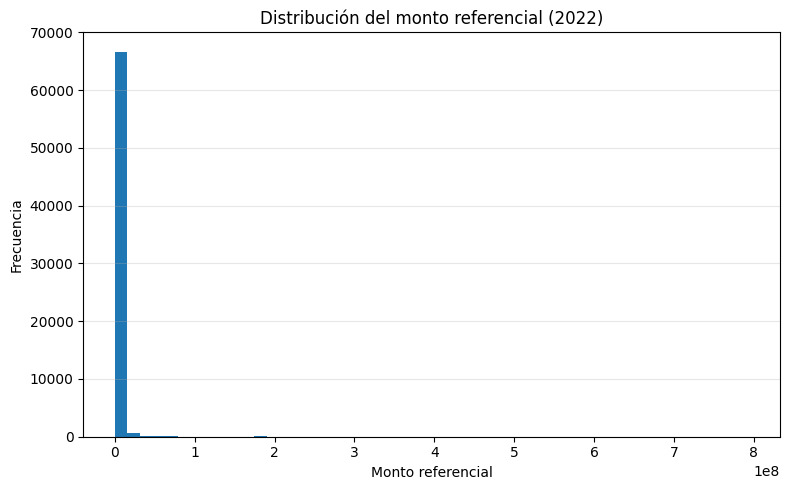

In [54]:
# ============================================================
# ESTADÍSTICA DE MONTOS
# ============================================================

if "monto_referencial_num" in base_trabajo_2022.columns:
    tabla_montos = pd.DataFrame([{
        "n_validos": base_trabajo_2022["monto_referencial_num"].notna().sum(),
        "promedio": base_trabajo_2022["monto_referencial_num"].mean(),
        "mediana": base_trabajo_2022["monto_referencial_num"].median(),
        "p25": base_trabajo_2022["monto_referencial_num"].quantile(0.25),
        "p75": base_trabajo_2022["monto_referencial_num"].quantile(0.75),
        "maximo": base_trabajo_2022["monto_referencial_num"].max()
    }])

    display(tabla_montos.round(2))
    tabla_montos.to_csv(
        RUTA_RESULTADOS_RESUMENES / "t2_parte3_resumen_montos.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(base_trabajo_2022["monto_referencial_num"].dropna(), bins=50)
    ax.set_title("Distribución del monto referencial (2022)")
    ax.set_xlabel("Monto referencial")
    ax.set_ylabel("Frecuencia")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_hist_monto_referencial.png", dpi=300, bbox_inches="tight")
    plt.show()

,token,frecuencia
0,distrito,25790
1,provincia,20869
2,departamento,16165
3,mejoramiento,14905
4,ejecucion,8245
5,proyecto,8147
6,mantenimiento,6511
7,cusco,5261
8,creacion,5204
9,centro,4694


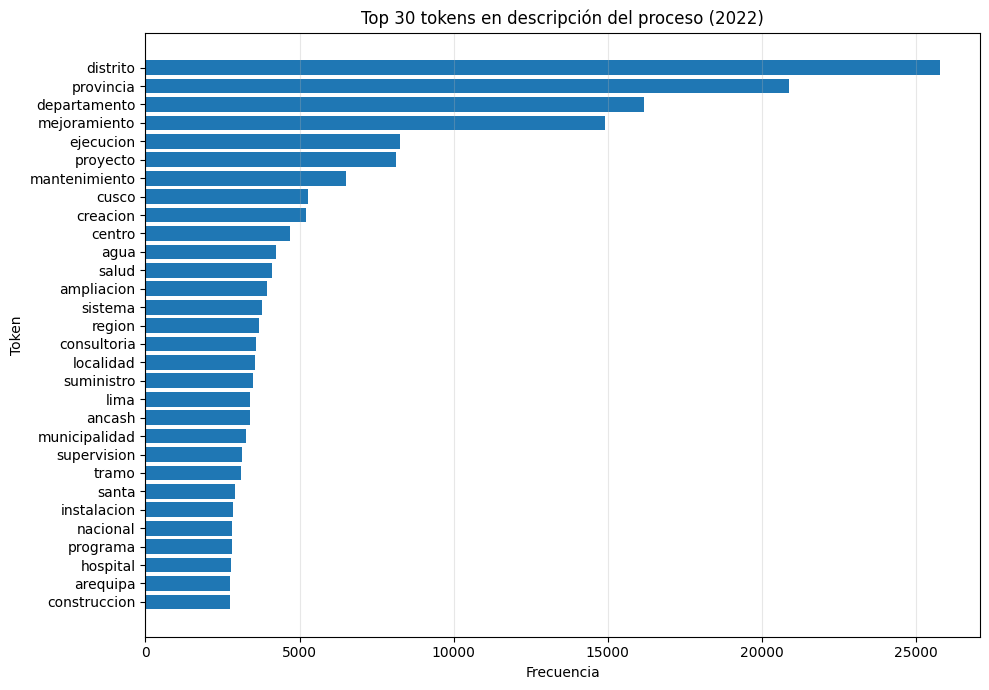

In [55]:
# ============================================================
# EXPLORACIÓN TEXTUAL BÁSICA
# ============================================================

from collections import Counter

STOPWORDS_ES = {
    "de", "la", "el", "los", "las", "y", "o", "u", "en", "del", "al", "por",
    "para", "con", "sin", "un", "una", "unos", "unas", "se", "su", "sus",
    "que", "como", "a", "ante", "bajo", "contra", "desde", "durante", "entre",
    "hacia", "hasta", "mediante", "sobre", "tras", "lo", "le", "les", "es", "son",
    "ha", "han", "fue", "ser", "sea"
}

STOPWORDS_ADMIN = {
    "contratacion", "proceso", "servicio", "servicios", "adquisicion", "obra", "obras",
    "convocatoria", "item", "entidad", "contrato", "publica", "publico", "seleccion"
}

STOPWORDS_TOTALES = STOPWORDS_ES.union(STOPWORDS_ADMIN)

if "descripcion_proceso_limpia" in base_trabajo_2022.columns:
    contador = Counter()

    for texto in base_trabajo_2022["descripcion_proceso_limpia"].fillna(""):
        tokens = [t for t in texto.split() if len(t) >= 4 and t not in STOPWORDS_TOTALES]
        contador.update(tokens)

    top_30 = pd.DataFrame(contador.most_common(30), columns=["token", "frecuencia"])
    display(top_30)

    top_30.to_csv(
        RUTA_RESULTADOS_TABLAS / "t2_parte3_top_tokens_descripcion_proceso.csv",
        index=False,
        encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_30["token"][::-1], top_30["frecuencia"][::-1])
    ax.set_title("Top 30 tokens en descripción del proceso (2022)")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Token")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(RUTA_RESULTADOS_FIGURAS / "t2_parte3_top_tokens_descripcion_proceso.png", dpi=300, bbox_inches="tight")
    plt.show()

In [56]:
# ============================================================
# EXPORTACIÓN FINAL DE OBJETOS PRINCIPALES
# ============================================================

base_principal_2022.to_csv(
    RUTA_TABLAS_UNIFICADAS / "t2_parte3_base_principal_todos_2022_raw.csv",
    index=False,
    encoding="utf-8"
)

base_trabajo_2022.to_csv(
    RUTA_TABLAS_LIMPIAS / "t2_parte3_base_principal_todos_2022_limpia.csv",
    index=False,
    encoding="utf-8"
)

base_paquetes_2022.to_csv(
    RUTA_TABLAS_UNIFICADAS / "t2_parte3_base_comparativa_paquetes_2022.csv",
    index=False,
    encoding="utf-8"
)

print("Objetos principales exportados correctamente.")

Objetos principales exportados correctamente.


In [57]:
# ============================================================
# BITÁCORA METODOLÓGICA DE LA PARTE 3
# ============================================================

bitacora_parte3 = pd.DataFrame([
    {
        "paso": 1,
        "descripcion": "Lectura y normalización de los tres paquetes 2022 descargados",
        "salida_principal": "Bases estandarizadas por paquete"
    },
    {
        "paso": 2,
        "descripcion": "Auditoría estructural y comparación de columnas",
        "salida_principal": "Tablas de auditoría y estructura"
    },
    {
        "paso": 3,
        "descripcion": "Construcción de una base comparativa apilada",
        "salida_principal": "Base comparativa de paquetes"
    },
    {
        "paso": 4,
        "descripcion": "Definición de la base principal de análisis",
        "salida_principal": "Base todos_los_procesos_2022"
    },
    {
        "paso": 5,
        "descripcion": "Selección e identificación de variables clave",
        "salida_principal": "Tabla de variables detectadas"
    },
    {
        "paso": 6,
        "descripcion": "Construcción de la base limpia de trabajo",
        "salida_principal": "Base_trabajo_2022"
    },
    {
        "paso": 7,
        "descripcion": "Producción de tablas y gráficos exploratorios",
        "salida_principal": "Resultados y figuras para presentación"
    }
])

display(bitacora_parte3)
bitacora_parte3.to_csv(
    RUTA_RESULTADOS_RESUMENES / "t2_parte3_bitacora_metodologica.csv",
    index=False,
    encoding="utf-8"
)

,paso,descripcion,salida_principal
0,1,Lectura y normalización de los tres paquetes 2022 descargados,Bases estandarizadas por paquete
1,2,Auditoría estructural y comparación de columnas,Tablas de auditoría y estructura
2,3,Construcción de una base comparativa apilada,Base comparativa de paquetes
3,4,Definición de la base principal de análisis,Base todos_los_procesos_2022
4,5,Selección e identificación de variables clave,Tabla de variables detectadas
5,6,Construcción de la base limpia de trabajo,Base_trabajo_2022
6,7,Producción de tablas y gráficos exploratorios,Resultados y figuras para presentación


## Cierre metodológico de la Parte 3/3 y de la Tarea 2

La tercera parte permitió cerrar la Tarea 2 transformando los paquetes descargados en objetos analíticos utilizables.

En lugar de tratar los tres archivos 2022 como universos equivalentes, se adoptó una decisión metodológica prudente: usar el archivo de **todos los procesos** como base principal y tratar los archivos de **subasta inversa electrónica** y **contratación directa** como subconjuntos comparativos. Esta decisión evitó la duplicación mecánica de registros y permitió distinguir entre universo principal y subconjuntos específicos.

A partir de ello, se normalizaron columnas, se identificaron variables clave, se construyó una tabla limpia de trabajo y se produjeron salidas exploratorias sobre distribución por objeto contractual, entidades, territorio, temporalidad, montos y vocabulario administrativo.

Con ello, la Tarea 2 queda cerrada como un ejercicio completo de:

1. justificación del cambio de base,
2. inspección de la página,
3. scraping y descarga controlada,
4. auditoría de archivos,
5. ensamblaje de base,
6. análisis exploratorio inicial.

La tarea no agota el portal OECE, pero sí demuestra de manera rigurosa, concreta y reproducible que el módulo de convocatorias puede convertirse en una fuente administrativa operativa para análisis aplicado en gestión pública.